<a href="https://colab.research.google.com/github/Rrg331/FPNSi/blob/main/FPNSi_PPGI_Artigo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Benchmarking Large Language Models for Business Process Modeling: A Comparative Study Based on Submodule 7.13 of the ONS Network Procedures

## Resumo

A aplicação de modelos de linguagem de grande escala (LLMs) a atividades de engenharia de requisitos e de modelagem de processos de negócio tem crescido. Falta avaliação em domínios técnicos fortemente regulados. O setor elétrico é um deles. Este artigo compara três LLMs (Claude Sonnet 4.6, Claude Haiku 4.5 e Llama 3.3 70B) na modelagem em BPMN do processo de emissão de declarações de atendimento aos Procedimentos de Rede para integração de instalações de geração ao Sistema Interligado Nacional, conforme o Submódulo 7.13 do ONS. Um modelo de referência foi elicitado do texto normativo e de entrevista com especialista de integração do ONS. As saídas dos modelos, obtidas com prompt padronizado em regime zero-shot e temperatura zero, foram confrontadas com essa referência por meio de cobertura, omissão, geração de elementos espúrios, precisão, revocação e F1. Os resultados indicam que o desempenho na extração documental escalou com a capacidade do modelo, com F1 de 0,800 para o Sonnet 4.6, 0,742 para o Haiku 4.5 e 0,538 para o Llama 3.3 70B. A estrutura explícita de atores, atividades e fluxos de exceção só foi capturada integralmente pelo modelo de maior capacidade, ao passo que as omissões se concentraram nos requisitos documentais. Nenhum dos três modelos reproduziu os requisitos implícitos da entrevista, fronteira esperada da extração documental.

**Palavras-chave:** modelos de linguagem de grande escala; modelagem de processos de negócio; engenharia de requisitos; BPMN; setor elétrico; ONS; Submódulo 7.13.

## Abstract

The use of large language models (LLMs) in requirements engineering and business process modeling has been growing, yet it remains underevaluated in highly regulated technical domains such as the electric power sector. This article compares three LLMs – Claude Sonnet 4.6, Claude Haiku 4.5, and Llama 3.3 70B – on the BPMN modeling of the process for issuing compliance declarations for the integration of generation facilities into the Brazilian National Interconnected System, as defined by ONS Network Procedures Submodule 7.13. A reference model was elicited from the regulatory text and from an interview with an ONS integration specialist; model outputs, obtained with a standardized zero-shot prompt at temperature zero, were compared against this reference using coverage, omission, spurious-element, precision, recall, and F1 measures. The results indicate that performance in document-based extraction scaled with model capacity, with F1 scores of 0.800 for Sonnet 4.6, 0.742 for Haiku 4.5, and 0.538 for Llama 3.3 70B; the explicit structure of actors, activities, and exception flows was fully captured only by the highest-capacity model, omissions concentrated in the documentary requirements, and none of the three models reproduced the implicit requirements from the interview, the expected boundary of document-based extraction.

**Keywords:** large language models; business process modeling; requirements engineering; BPMN; electric power sector; ONS; Submodule 7.13.

## 1 Introdução

### 1.1 Contextualização e Motivação

O Operador Nacional do Sistema Elétrico (ONS) é a entidade responsável pela coordenação e pelo controle da operação do Sistema Interligado Nacional (SIN), atuando sob regulação e fiscalização da Agência Nacional de Energia Elétrica (ANEEL). No exercício dessa atribuição, o ONS edita e mantém os Procedimentos de Rede, conjunto de documentos normativos que padronizam as atividades técnicas e operacionais necessárias ao funcionamento do sistema. Entre esses documentos está o Submódulo 7.13. Em sua revisão 2026.04, aprovada pelo Despacho STD nº 1.238/2026, ele disciplina a emissão, pelo ONS, das declarações de atendimento aos Procedimentos de Rede exigidas para a integração de instalações de geração ao SIN.

A integração de uma usina ao sistema percorre um caminho que vai do parecer de acesso e da contratação do uso da transmissão à autorização da ANEEL e à construção do empreendimento, culminando na avaliação dos requisitos técnicos e regulatórios que condicionam a entrada em operação. Tal percurso se materializa em quatro tipos de declaração. A Declaração de Inexistência de Relacionamento Operacional (DIR) destina-se a usinas sem impacto relevante sobre o sistema. As Declarações de Atendimento aos Procedimentos de Rede, por sua vez, cobrem a operação em teste (DAPR/T), a provisória (DAPR/P) e a definitiva (DAPR/D). A análise que precede cada emissão confronta a solicitação do agente de geração, instruída pelo Anexo A, com um rol de requisitos impeditivos descritos no Anexo B, cujo número varia de 38 a 41 conforme a modalidade de operação da instalação. Esses requisitos abrangem desde a conformidade com o ato autorizativo e o parecer de acesso até medição para faturamento, telecomunicação, supervisão e controle, testes de comissionamento e estudos pré-operacionais.

O processo é, ao mesmo tempo, normativamente denso e operacionalmente crítico. A correta interpretação dos Procedimentos de Rede determina a regularidade da entrada de novos empreendimentos no SIN e, com ela, a segurança da operação do sistema como um todo. Modelar esse fluxo em notação BPMN (Business Process Model and Notation) oferece uma representação formal e auditável das atividades, atores, decisões e fluxos de exceção envolvidos, condição necessária tanto para a transparência regulatória quanto para iniciativas de automação.

A engenharia de requisitos há tempos reconhece que a elicitação e a representação de processos a partir de fontes textuais e de conhecimento tácito constituem etapas custosas e propensas a erro (NUSEIBEH; EASTERBROOK, 2000). Os modelos de linguagem de grande escala (LLMs) têm sido investigados como apoio a essas atividades, com resultados promissores na elicitação de requisitos (RONANKI; BERGER; HORKOFF, 2023), na geração de histórias de usuário (SANTOS et al., 2025) e na modelagem em UML (OLIVEIRA, 2024), além de revisões sistemáticas que mapeiam o estado da arte (KHAN; QAYYUM; DAR, 2024; ZADENOORI et al., 2025). A aplicação de LLMs a processos normativos do setor elétrico, porém, permanece pouco explorada. As experiências documentadas em redes inteligentes são incipientes (KUCHENBUCH; LEHNHOFF; SAUER, 2025), e não se identificam estudos que avaliem o desempenho desses modelos na modelagem de processos regidos por documentos regulatórios como os Procedimentos de Rede do ONS. É essa lacuna que motiva o presente trabalho.

### 1.2 Objetivo Geral

O objetivo geral deste artigo é avaliar comparativamente o desempenho de três modelos de linguagem de grande escala na modelagem, em notação BPMN, do processo de emissão de declarações de atendimento aos Procedimentos de Rede para integração de instalações de geração ao SIN, conforme o Submódulo 7.13 dos Procedimentos de Rede do ONS, tomando como referência um modelo construído e validado por especialista da área.

### 1.3 Objetivos Específicos

Para alcançar o objetivo geral, definem-se os seguintes objetivos específicos:

(a) elaborar um modelo de referência (ground truth) do processo do Submódulo 7.13 em notação BPMN, a partir do documento normativo e de entrevista de elicitação com especialista de integração do ONS, contemplando atores, atividades, gateways, eventos, fluxos de exceção e requisitos documentais e implícitos;

(b) submeter os três modelos de linguagem a um prompt padronizado e idêntico, em abordagem zero-shot e com temperatura fixada em zero, obtendo de cada um a modelagem do processo no formato estruturado especificado;

(c) realizar o pareamento requisito a requisito entre cada saída gerada e o modelo de referência, computando as métricas de cobertura, omissão, geração de elementos espúrios, precisão, revocação e F1;

(d) analisar e comparar os resultados, discutindo as forças e limitações de cada modelo, as ameaças à validade do método de avaliação e as implicações para o emprego de LLMs em processos normativos do setor elétrico.

### 1.4 Justificativa

A relevância do tema decorre da escala do problema. A equipe do ONS responsável pela integração de instalações recebe da ordem de sessenta solicitações por mês apenas no segmento de geração, e a mesma equipe atende ainda transmissão, consumidores e distribuidoras. Cada solicitação exige a verificação de dezenas de requisitos contra um documento normativo extenso. A fase de testes é a mais trabalhosa. É também a que concentra o maior número de pendências. Ferramentas capazes de apoiar a interpretação dos Procedimentos de Rede e a estruturação do processo têm, portanto, potencial direto de aliviar uma carga de trabalho expressiva e recorrente.

Há, contudo, uma dimensão que vai além da eficiência. Pendências classificadas como não impeditivas, associadas à operação provisória, podem perdurar por anos quando faltam incentivos regulatórios à sua resolução. Tal acúmulo de adequações não concluídas contribuiu para o apagão de agosto de 2023, episódio após o qual os processos foram revistos para penalizar agentes que deixam pendências sem solução. O caso evidencia que falhas no tratamento e no acompanhamento dos requisitos de integração extrapolam o âmbito administrativo e configuram fatores de risco sistêmico para o SIN. Representar com fidelidade esse processo e compreender em que medida LLMs conseguem capturá-lo é um passo necessário para qualquer iniciativa de automação que pretenda atuar sobre ele com segurança.

O próprio ONS já caminha nessa direção, com o desenvolvimento do sistema SG Integração, que prevê interligação com bases da ANEEL, contratos e pareceres, automação da criação de processos e do envio de liberações, além de experiências pontuais de uso de inteligência artificial na interpretação de documentos autorizativos. A prática da área distingue os requisitos objetivos do tipo verificação imediata, que se prestam à automação, daqueles que demandam estudo elétrico aprofundado e avaliação de especialista. A distinção define precisamente o espaço em que ferramentas baseadas em LLMs podem ou não contribuir. Avaliar empiricamente o desempenho desses modelos na modelagem do Submódulo 7.13 oferece subsídios concretos para delimitar esse espaço, contribuindo tanto para a literatura de engenharia de requisitos apoiada por LLMs quanto para as decisões de automação no contexto regulatório do setor elétrico brasileiro.

### 1.5 Estrutura do Artigo

O artigo está organizado em sete seções. Esta primeira seção contextualiza o problema, delimita os objetivos e apresenta a justificativa. A seção seguinte revisa a fundamentação teórica sobre engenharia de requisitos, modelagem de processos de negócio e o uso de modelos de linguagem de grande escala nessas atividades. A terceira descreve o processo estudado, situando o Submódulo 7.13 no conjunto dos Procedimentos de Rede do ONS. A metodologia vem na quarta seção, da elicitação com o especialista ao protocolo de métricas. A quinta apresenta os resultados, a sexta discute os achados e as ameaças à validade, e a sétima encerra com as conclusões e as perspectivas de trabalhos futuros.

## 2 Referencial Teórico

### 2.1 Engenharia de Requisitos

A engenharia de requisitos ocupa-se da descoberta, do registro, da análise e da manutenção das propriedades que um sistema deve exibir e das restrições sob as quais deve operar. Nuseibeh e Easterbrook (2000) descrevem o campo como um conjunto coordenado de atividades, a saber, elicitação, modelagem e análise, comunicação e validação, além da gestão da evolução dos requisitos, que raramente se sucedem de modo linear e que se realimentam ao longo do ciclo de vida. Os autores enfatizam que requisitos não emergem de um documento isolado. Eles brotam de um contexto social e organizacional, de sorte que a qualidade do produto final depende menos da formalização precoce e mais da capacidade de reconciliar perspectivas de múltiplos interessados.

A dimensão social explica por que a elicitação costuma ser a fase mais sensível. O conhecimento relevante está distribuído entre atores que o expressam em vocabulário próprio, com lacunas, pressupostos tácitos e eventuais contradições. Técnicas como entrevistas, observação e análise documental servem justamente para tornar explícito tal conhecimento. A entrevista semiestruturada, empregada neste trabalho com um especialista de integração do ONS, combina um roteiro de tópicos com liberdade para que o entrevistado conduza a conversa a aspectos que o pesquisador não anteciparia. O instrumento é adequado a domínios regulados, nos quais a norma escrita convive com práticas operacionais e com conhecimento sobre o porquê das regras que não se encontra no texto normativo.

Distingue-se, na prática, entre requisitos explícitos, ancorados em fontes documentais verificáveis, e requisitos implícitos, que só afloram na interação com quem executa o processo. No caso aqui estudado, o Submódulo 7.13 dos Procedimentos de Rede fornece a base documental, ao passo que a entrevista revela elementos que o texto regulatório não expressa diretamente, como qual fase concentra mais pendências ou quais requisitos comportam automação. A validação encerra o ciclo descrito por Nuseibeh e Easterbrook (2000). Consiste em confrontar o modelo construído com essas fontes para verificar se ele de fato captura o que importa, sem introduzir o que não existe.

### 2.2 Modelagem de Processos de Negócio

Modelar um processo de negócio é representar, de forma estruturada, a sequência de atividades, os atores responsáveis, as decisões e os eventos que transformam entradas em resultados de valor para uma organização. A modelagem cumpre papel de elicitação e de comunicação. O ato de desenhar o fluxo força a explicitação de regras antes implícitas, e o artefato resultante serve de linguagem comum entre analistas, especialistas de domínio e responsáveis pela operação.

Entre as notações disponíveis, três merecem registro. A UML (Unified Modeling Language), originada na engenharia de software, oferece diagramas de atividades e de casos de uso aplicáveis a processos, mas seu foco recai sobre a estrutura e o comportamento de sistemas. A KMDL (Knowledge Modeling and Description Language) acrescenta a perspectiva do conhecimento ao distinguir conversões entre conhecimento tácito e explícito ao longo das atividades, o que a torna útil em processos intensivos em conhecimento, ainda que ao custo de maior complexidade de leitura. Já a BPMN (Business Process Model and Notation) consolidou-se como o padrão de fato para a modelagem de processos de negócio por equilibrar expressividade e legibilidade.

A escolha da BPMN neste trabalho decorre dessa adequação. Sua gramática visual organiza o fluxo em raias (lanes e pools) que atribuem responsabilidade a cada ator, que no processo estudado são o agente de geração, o ONS, a ANEEL e a CCEE. As atividades representam o trabalho realizado; os gateways exprimem decisões e bifurcações, como a verificação de existência de pendências impeditivas; e os eventos marcam inícios, intermediários e fins, inclusive os de exceção. A capacidade de modelar caminhos alternativos e de exceção é decisiva no domínio em questão, no qual a presença de pendência impeditiva suspende o processo e exige reinício, enquanto pendências não impeditivas conduzem a um ramo distinto, com prazos acordados e possibilidade de revalidação. Representar esses desvios de forma explícita é parte central daquilo que se espera de um modelo fiel do Submódulo 7.13.

### 2.3 LLMs em Engenharia de Requisitos e Modelagem de Processos

O uso de grandes modelos de linguagem (LLMs) na engenharia de requisitos cresceu rapidamente após a popularização de assistentes conversacionais baseados em transformadores. Khan, Qayyum e Dar (2024), em revisão sistemática da literatura, mapeiam aplicações que vão da elicitação à classificação e à validação de requisitos, e identificam ganhos de produtividade acompanhados de limitações recorrentes, entre elas a sensibilidade ao prompt, a inconsistência entre execuções e a produção de conteúdo plausível porém incorreto. Zadenoori et al. (2025) chegam a conclusões convergentes em revisão mais recente, ao observar que a maturidade das avaliações ainda é baixa e que faltam estudos em domínios especializados.

A linha de pesquisa de Ronanki e colaboradores fornece evidência experimental sobre a elicitação. Ronanki, Berger e Horkoff (2023) investigam o potencial do ChatGPT para auxiliar a elicitação de requisitos e constatam que o modelo gera requisitos pertinentes e bem redigidos, embora tenda a permanecer em nível genérico e a omitir restrições específicas do contexto. Ronanki (2024), em sua dissertação de licenciatura, consolida a agenda e argumenta que os LLMs se prestam melhor ao papel de assistente, sob supervisão humana, do que ao de agente autônomo. Santos et al. (2025) examinam a geração de histórias de usuário e relatam que o ChatGPT produz artefatos de qualidade comparável à de redatores humanos em critérios formais, mas alertam para a necessidade de revisão quanto à completude e à aderência ao domínio.

No território da modelagem, os trabalhos brasileiros oferecem aproximações diretas. Oliveira (2024) aplica LLMs à modelagem de requisitos em UML e observa que os modelos capturam bem estruturas típicas, mas requerem intervenção para corrigir relacionamentos e suprir elementos ausentes. Silva (2025) avalia o uso de LLMs em atividades de engenharia de requisitos e reporta resultados úteis sob curadoria humana, o que reforça o padrão assistente-supervisor. Kuchenbuch, Lehnhoff e Sauer (2025) aproximam-se do domínio deste estudo ao propor IA assistiva para engenharia de requisitos em redes inteligentes (smart grid), e mostram que a especificidade técnica e regulatória do setor elétrico impõe desafios que modelos de propósito geral não resolvem sem apoio de conhecimento de domínio.

O conjunto da literatura aponta convergência em torno do potencial dos LLMs como apoio e em torno de suas limitações em precisão, consistência e cobertura. Permanece, contudo, uma lacuna. Há pouca investigação sobre o desempenho desses modelos na modelagem de processos de negócio em domínios regulatórios de infraestrutura crítica, nos quais a fidelidade ao texto normativo, o tratamento correto de fluxos de exceção e a captura de conhecimento tácito de especialistas são simultaneamente exigidos. O benchmark proposto neste trabalho situa-se exatamente nessa lacuna, ao confrontar três LLMs com um modelo de referência do Submódulo 7.13 dos Procedimentos de Rede do ONS.

### 2.4 Métricas de Avaliação

A avaliação de saídas de LLMs em tarefas de modelagem combina medidas quantitativas e análise qualitativa. As métricas quantitativas adotadas neste trabalho derivam do confronto, requisito a requisito, entre cada modelo gerado e o modelo de referência. A taxa de cobertura de requisitos (TCR) mede a proporção de elementos da referência efetivamente representados na saída. A taxa de requisitos omitidos (TRO) é seu complemento e indica o que o modelo deixou de capturar. Já a taxa de elementos espúrios (TEE) quantifica os elementos presentes na saída sem correspondência na referência, ou seja, as alucinações e as invenções.

Sobre essa base aplicam-se as métricas clássicas de recuperação de informação. A precisão expressa a fração de elementos gerados que estão corretos, penalizando alucinações; a revocação expressa a fração de elementos da referência que foram recuperados, penalizando omissões; o F1, média harmônica das duas, sintetiza o equilíbrio entre não inventar e não omitir. Em modelagem de processos esse equilíbrio é informativo. Um modelo pode exibir alta revocação acompanhada de baixa precisão quando enumera elementos em excesso, ou o inverso quando se mostra conservador.

As métricas numéricas, porém, não capturam tudo. A correta representação da topologia do fluxo, em particular dos caminhos de exceção, como suspensão e reinício do processo ou a bifurcação entre operação provisória e definitiva, e a aderência ao vocabulário do domínio são dimensões qualitativas que exigem inspeção. A própria contagem requisito a requisito, neste estudo, foi realizada por um avaliador LLM atuando como juiz. A escolha introduz uma ameaça à validade, porque o juiz pode herdar vieses dos próprios modelos avaliados e classificar correspondências de forma inconsistente. A limitação é discutida adiante, e a leitura das métricas é feita à luz dela.

### 2.5 Engenharia de Prompts

A qualidade das saídas de um LLM depende fortemente da formulação da instrução, o que fez emergir a engenharia de prompts como prática deliberada. Arvidsson e Axell (2023) sistematizam diretrizes de construção de prompts para engenharia de requisitos e observam que instruções que delimitam papel, tarefa, contexto e formato de saída produzem resultados mais consistentes e reaproveitáveis do que solicitações vagas. Entre as técnicas usuais figuram o role prompting, que atribui ao modelo uma persona especializada; o few-shot, que fornece exemplos resolvidos; o zero-shot, que descreve a tarefa sem exemplos; e o chain-of-thought, que solicita raciocínio intermediário explícito.

O desenho experimental deste trabalho adota role prompting combinado à abordagem zero-shot. Atribui-se a cada modelo o papel de especialista em BPMN no setor elétrico, fornece-se o documento integral do Submódulo 7.13 e especifica-se um formato de saída estruturado em raias, atividades, gateways, eventos e fluxos de exceção. Opta-se por zero-shot, sem exemplos resolvidos e sem refinamento iterativo, registrando-se a primeira resposta de cada modelo. A temperatura é fixada em zero para favorecer a reprodutibilidade e reduzir a variabilidade entre execuções. A ausência deliberada de exemplos e de iteração isola a capacidade dos modelos de modelar o processo a partir apenas da norma e da instrução, o que torna a comparação entre eles mais direta, ainda que ao custo de não explorar o potencial de melhoria que o refinamento ou o few-shot poderiam trazer, limite assumido e coerente com o objetivo de benchmark.

## 3 O Processo de Emissão de Declarações de Atendimento aos Procedimentos de Rede

### 3.1 O ONS

Cabe ao Operador Nacional do Sistema Elétrico coordenar e controlar a operação das instalações de geração e de transmissão do Sistema Interligado Nacional (SIN). Entre suas atribuições está a integração de novas instalações ao sistema, atividade que condiciona a entrada em operação de usinas, linhas de transmissão e demais empreendimentos à verificação de um conjunto de requisitos técnicos e regulatórios. A verificação não é discricionária. O ONS atua vinculado aos Procedimentos de Rede, documento normativo que disciplina as relações entre o operador e os agentes do setor.

A integração de uma instalação de geração percorre uma cadeia que começa muito antes da solicitação formal ao operador. Conforme relatado por especialista da área de integração do ONS em entrevista que subsidiou este trabalho, o empreendimento parte de um parecer de acesso, passa pela celebração de contratos, pela autorização da ANEEL e pela construção física, até chegar à etapa de avaliação dos requisitos que habilitam a operação. O volume é expressivo. A equipe responsável processa cerca de sessenta solicitações por mês apenas em geração, atendendo simultaneamente às demandas de transmissão, consumidores livres e distribuidoras. Há, ainda, esforço de modernização em curso, com o desenvolvimento de um novo sistema computacional ("SG Integração") que pretende integrar bases da ANEEL, contratos e pareceres de acesso, automatizando a criação de processos e o envio de liberações.

### 3.2 Os Procedimentos de Rede e o Módulo 7

Os Procedimentos de Rede são o conjunto de documentos técnico-normativos que estabelecem os requisitos para o planejamento, a implantação e a operação do SIN, organizando as responsabilidades do ONS e dos agentes. Eles se estruturam em módulos temáticos, periodicamente revisados e aprovados por despacho da ANEEL.

O Módulo 7 trata especificamente da integração de instalações ao sistema. Nele se encontram, entre outros, o Submódulo 7.2, que define as modalidades de operação das instalações de geração (Tipo I, Tipo II-A, Tipo II-B, Tipo II-C e Tipo III), o Submódulo 7.4, que regula os estudos pré-operacionais, e o Submódulo 7.13, objeto deste trabalho, que disciplina a emissão, pelo ONS, das declarações de atendimento aos Procedimentos de Rede. A interdependência entre esses submódulos pesa na modelagem. A declaração de operação definitiva, por exemplo, está vinculada à conclusão dos estudos pré-operacionais previstos no Submódulo 7.4, e o enquadramento da instalação em uma das modalidades do Submódulo 7.2 determina quais requisitos lhe são exigíveis.

### 3.3 Submódulo 7.13

O Submódulo 7.13, em sua revisão 2026.04, aprovada pelo Despacho STD nº 1.238/2026, com vigência a partir de 1º de maio de 2026, disciplina a emissão das declarações de atendimento aos Procedimentos de Rede para a integração de instalações de geração ao SIN. O submódulo prevê quatro declarações, associadas a diferentes situações operativas.

A Declaração de Inexistência de Relacionamento Operacional (DIR) destina-se a usinas que não estabelecem relacionamento operacional relevante com o operador. Aplica-se à usina classificada na modalidade Tipo III conectada à Rede de Distribuição, bem como ao produtor independente ou autoprodutor que opere, por tempo determinado, sem injeção de potência no SIN. Segundo o especialista entrevistado, a DIR atende usinas sem impacto relevante sobre o sistema.

As Declarações de Atendimento aos Procedimentos de Rede (DAPR) habilitam o início da operação propriamente dita e se subdividem conforme o regime pretendido. A DAPR/T autoriza o início da operação em teste. A DAPR/P autoriza o início da operação provisória e admite pendências não impeditivas, com prazos acordados, adequações e eventuais restrições de escoamento; o prazo associado a essa operação pode ser revalidado pela ANEEL até duas vezes, mediante justificativa. A DAPR/D autoriza o início da operação definitiva, não admite pendências e fica condicionada à conclusão, sem pendências, dos estudos pré-operacionais do Submódulo 7.4.

O fluxo de solicitação, análise e emissão é o eixo que a modelagem precisa capturar. O agente de geração encaminha ao ONS a solicitação acompanhada do ANEXO A, que reúne o informe e os dados técnicos da instalação. O ONS analisa os requisitos impeditivos relacionados no ANEXO B e, conforme o resultado, emite a declaração ou informa a inviabilidade e os impedimentos identificados. Havendo pendência impeditiva, o operador suspende o processo e somente o reinicia após a confirmação da solução e a apresentação de nova solicitação por meio do sistema computacional do ONS. Quando o operador verifica que não há pendências para a operação integrada, emite diretamente a DAPR/D, sem a passagem pelos regimes intermediários.

A Tabela 1 sintetiza as etapas associadas a cada declaração.

**Tabela 1 – Etapas do processo de emissão de declarações (Submódulo 7.13)**

| Etapa | Responsável | Entrada | Saída | Critério de aceite |
|---|---|---|---|---|
| DIR | ONS | Solicitação do agente com ANEXO A; enquadramento como Tipo III na Rede de Distribuição ou operação por tempo determinado sem injeção de potência no SIN | Declaração de Inexistência de Relacionamento Operacional | Ausência de relacionamento operacional relevante com o SIN |
| DAPR/T | ONS | Solicitação do agente com ANEXO A para operação em teste | Declaração para início da operação em teste | Atendimento aos requisitos do ANEXO B marcados como impeditivos para a DAPR/T |
| DAPR/P | ONS, com revalidação de prazo pela ANEEL | Solicitação do agente com ANEXO A para operação provisória; pendências não impeditivas com prazos e adequações acordados | Declaração para início da operação provisória, com prazos, adequações e eventuais restrições de escoamento | Atendimento aos requisitos do ANEXO B marcados como impeditivos para a DAPR/P; pendências remanescentes restritas às não impeditivas |
| DAPR/D | ONS | Solicitação do agente com ANEXO A para operação definitiva; estudos pré-operacionais (Submódulo 7.4) concluídos | Declaração para início da operação definitiva | Inexistência de pendências e conclusão sem pendências dos estudos pré-operacionais |

### 3.4 Complexidade e Desafios de Modelagem

O fluxo parece linear, da solicitação à análise e à emissão. A aparência engana. Por baixo dela, a complexidade real do processo se manifesta em ao menos quatro frentes e impõe desafios concretos a qualquer tentativa de modelagem em BPMN.

A primeira frente é a variabilidade por modalidade. O enquadramento da instalação em uma das modalidades do Submódulo 7.2 (Tipo I, Tipo II-A, Tipo II-B, Tipo II-C e Tipo III) condiciona o conjunto de requisitos aplicáveis. O ANEXO B relaciona entre 38 e 41 requisitos impeditivos por modalidade, e cada requisito é marcado conforme impeça a emissão da DAPR/T, da DAPR/P, da DAPR/D ou de mais de uma delas. Trata-se de um mapeamento tridimensional, que cruza modalidade, requisito e declaração afetada e multiplica os caminhos possíveis. Uma modelagem ingênua raramente o representa de forma fiel, pois tende a colapsar a análise em uma única atividade genérica.

O conteúdo desses requisitos é, por si só, denso. O ANEXO B abrange conformidade com o ato autorizativo e a outorga; designação de interlocutores; parecer de acesso à Rede Básica, à Instalação de Conexão Compartilhada (ICG) ou às Demais Instalações de Transmissão (DIT), com atendimento a ressalvas e pendências; instrumento de garantia financeira e contrato de uso do sistema de transmissão (CUST) com montante de uso (MUST) vigente; inexistência de inadimplência nos encargos de transmissão; contrato de conexão à transmissão (CCT); diagramas unifilares pré-operacional e operacional; medição para faturamento, com aprovação de projeto e cadastro do ponto na CCEE; telecomunicação, incluindo canais de dados e de voz; supervisão e controle, com base de dados, teste ponto a ponto e sequência de eventos (SOE); intervenções para teste; instruções de operação; teste de 96 horas; dados anemométricos e solarimétricos; monitoração contínua de qualidade de energia; campanhas de qualidade de energia anteriores e posteriores à energização; compensação de reativo e filtros para qualidade de energia em usinas eólicas e solares; modelos para simulação e respectivo relatório de validação; relatório de comissionamento; estudos pré-operacionais do Submódulo 7.4; dados hidrológicos e de vento; áreas de desenvolvimento da subestação (ADS); e regime de assistência ou teleassistência. Terminologia desse porte, fortemente ancorada no domínio do setor elétrico, é uma fonte recorrente de imprecisão e de alucinação quando o processo é modelado por sistemas que não dominam o jargão.

A segunda frente são os fluxos de exceção, que constituem a parte verdadeiramente discriminante do processo. Cinco situações merecem representação explícita. A pendência impeditiva leva à não emissão da declaração. A suspensão do processo dura até a confirmação da solução e a nova solicitação via sistema computacional do ONS. A pendência não impeditiva redireciona o agente para a operação provisória sob a DAPR/P, com prazo associado. A revalidação desse prazo cabe à ANEEL, em até duas vezes, mediante justificativa. E há ainda a comunicação à ANEEL. Tais desvios capturam a lógica de tratamento de pendências que diferencia um modelo apenas plausível de um modelo fiel ao procedimento.

A terceira frente diz respeito ao conhecimento que não está no texto normativo, mas emergiu da elicitação com o especialista. Foram identificados três requisitos implícitos. A fase de testes, vinculada à DAPR/T, é a etapa mais trabalhosa e a que concentra o maior número de pendências, da ordem de trinta requisitos. As pendências não impeditivas, próprias da operação provisória, podem perdurar por anos por falta de incentivos regulatórios à sua resolução; essa permanência contribuiu para o apagão de agosto de 2023 e, após o evento, os processos foram alterados para penalizar agentes que não solucionam suas pendências. Cabe ainda distinguir requisitos automatizáveis de não automatizáveis. Requisitos objetivos, de verificação binária (do tipo "tem ou não tem"), são candidatos naturais à automação, ao passo que requisitos que demandam estudo elétrico mais aprofundado seguem exigindo a avaliação de um especialista humano. Ausente do submódulo, esse conhecimento integra o modelo de referência e serve de critério para avaliar até que ponto as saídas dos LLMs incorporam a perspectiva de quem opera o processo.

A quarta frente é a articulação entre atores. O processo envolve o agente de geração, o ONS, a ANEEL, a CCEE e as concessionárias de transmissão e distribuição, com responsabilidades distribuídas e dependências cruzadas. A revalidação de prazos pela ANEEL e o cadastro de pontos de medição na CCEE são exemplos de etapas cuja autoria precisa ser corretamente atribuída em raias separadas. Em conjunto, a variabilidade por modalidade, a densidade terminológica, os fluxos de exceção, os requisitos implícitos e a distribuição de responsabilidades definem o espaço de dificuldade contra o qual o desempenho dos três modelos será medido.

## 4 Metodologia

### 4.1 Visão Geral

A pesquisa adota uma abordagem mista, que combina elicitação qualitativa com um especialista do domínio e avaliação quantitativa do desempenho de modelos de linguagem na tarefa de modelagem de processos. O percurso metodológico está sintetizado na Figura 1. Parte da construção de um modelo de referência em BPMN e chega à comparação sistemática desse modelo com as saídas geradas por três LLMs.

A etapa inicial consiste em elicitar e consolidar o conhecimento do processo de emissão de declarações de atendimento aos Procedimentos de Rede, regido pelo Submódulo 7.13. A elicitação ampara-se em duas fontes complementares. Uma é o texto integral do submódulo, que fornece os requisitos documentais e regulatórios formais. A outra é uma entrevista semiestruturada com especialista da área de integração de geração do ONS, que traz o conhecimento tácito sobre a operação cotidiana do processo. Dessas fontes deriva-se o modelo de referência, validado pelo próprio especialista.

A etapa seguinte submete as três LLMs a um mesmo estímulo, um prompt padronizado contendo o papel a ser assumido, a tarefa de modelagem, o documento do Submódulo 7.13 e o formato de saída esperado. Cada modelo produz uma única resposta, em regime zero-shot e com temperatura fixada em zero, sem qualquer refinamento posterior. As saídas são então confrontadas com o modelo de referência por meio de um procedimento de correspondência requisito a requisito, do qual se extraem as métricas de cobertura, omissão, geração de elementos espúrios, precisão, revocação e F1. A análise comparativa final articula esses indicadores quantitativos a uma apreciação qualitativa das saídas, sustentando a discussão sobre a viabilidade do uso de LLMs como apoio à modelagem de processos no setor elétrico.

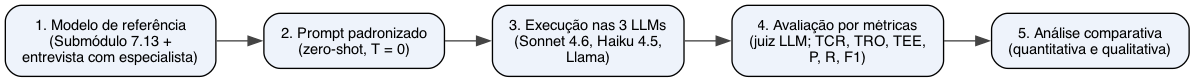

### 4.2 Construção do Modelo de Referência

O modelo de referência cumpre, neste estudo, a função de padrão-ouro. É o artefato contra o qual o desempenho das LLMs é medido. Sua construção precisava conjugar o rigor normativo do texto regulatório com a fidelidade ao processo tal como praticado, razão pela qual se recorreu tanto à leitura do submódulo quanto à elicitação junto a um especialista.

#### 4.2.1 Perfil do Especialista e Critérios de Seleção

A entrevista foi conduzida com Vinícius Magalhães da Cruz, especialista de integração da área de geração do ONS. A seleção do entrevistado obedeceu a três critérios. Pesou, antes de tudo, a atuação direta no processo objeto da modelagem, já que o especialista participa rotineiramente da análise das solicitações de integração de instalações de geração e da emissão das declarações de atendimento previstas no Submódulo 7.13. Contou também a abrangência da experiência, que cobre desde o exame do parecer de acesso e dos contratos até a avaliação dos requisitos técnicos e regulatórios das diferentes modalidades de operação. O mais decisivo, porém, foi a familiaridade com as situações de exceção e com o tratamento de pendências, conhecimento que raramente está explicitado no texto normativo e que se mostrou indispensável para representar fielmente o fluxo do processo.

#### 4.2.2 Protocolo da Entrevista Semiestruturada

A entrevista seguiu um roteiro semiestruturado, organizado em blocos temáticos que permitiam aprofundamento conforme as respostas conduzissem a aspectos relevantes. O primeiro bloco tratou da visão geral do processo de integração, percorrendo a sequência que vai do parecer de acesso, do contrato e da autorização da ANEEL à construção da instalação e à avaliação final dos requisitos. O segundo bloco concentrou-se nos tipos de declaração (DIR, DAPR/T, DAPR/P e DAPR/D) e nas condições que distinguem cada um, com atenção à fase de testes, descrita pelo especialista como a etapa mais trabalhosa e a que concentra o maior número de pendências. O terceiro bloco abordou o tratamento de pendências, diferenciando as impeditivas, que suspendem o processo, das não impeditivas, que admitem operação provisória. Nesse ponto o especialista observou que pendências não impeditivas podem perdurar por anos e que tal lacuna de incentivos regulatórios contribuiu para o apagão de agosto de 2023, evento que motivou ajustes posteriores no processo para penalizar agentes que não as resolvem. O quarto bloco investigou o volume de trabalho e os sistemas de apoio, registrando o patamar de cerca de sessenta solicitações mensais em geração e o desenvolvimento do novo sistema SG Integração, com integração às bases da ANEEL e automação da criação de processos. O bloco final discutiu os limites da automação, distinguindo os requisitos objetivos, do tipo verifica-se ou não a existência de um documento, daqueles que demandam estudo elétrico aprofundado e permanecem dependentes do julgamento de um especialista humano.

#### 4.2.3 Análise Temática e Consolidação em BPMN

As respostas foram submetidas a análise temática, na qual os trechos da entrevista foram codificados e agrupados em categorias que dialogavam com os elementos do processo já identificados no texto do submódulo. A codificação permitiu reconciliar duas perspectivas, a estrutura formal prescrita pela norma e a dinâmica observada na prática, incluindo os caminhos de exceção. O resultado foi consolidado em um modelo BPMN, posteriormente submetido ao especialista para validação, etapa que assegurou a aderência do artefato ao processo real e corrigiu interpretações equivocadas surgidas na codificação.

O modelo de referência resultante reúne 36 elementos, distribuídos em cinco categorias. São quatro atores, representados nas raias do diagrama: o agente de geração, o ONS, a ANEEL e a CCEE. As atividades somam quatorze (P1 a P14) e cobrem a solicitação, a análise e a emissão das declarações DIR, DAPR/T, DAPR/P e DAPR/D, incluindo a operação em teste, o teste de 96 horas, o tratamento de pendências não impeditivas com prazos e a emissão direta da declaração definitiva quando inexistem pendências. Os fluxos de exceção são cinco (E1 a E5), a saber, a não emissão diante de pendência impeditiva, a suspensão e o reinício do processo, a emissão de DAPR/P com prazo em razão de pendência não impeditiva, a revalidação de prazo pela ANEEL em até duas vezes e a comunicação à ANEEL. Completam o modelo dez requisitos documentais e regulatórios (R1 a R10), extraídos sobretudo dos itens impeditivos do Anexo B, e três requisitos implícitos derivados da entrevista (I1 a I3): o caráter mais trabalhoso da fase de teste, a permanência de pendências por anos com o consequente risco sistêmico e a distinção entre o que é automatizável e o que exige avaliação especializada.

### 4.3 Seleção das LLMs

A escolha dos modelos buscou contemplar diferentes patamares de capacidade e custo, mantendo controle sobre a infraestrutura de inferência. Foram selecionados três modelos, acessados por meio de provedores de nuvem, conforme a Tabela 2.

**Tabela 2 – Modelos de linguagem avaliados**

| Modelo | Identificador | Provedor de acesso |
|---|---|---|
| Claude Sonnet 4.6 | `us.anthropic.claude-sonnet-4-6` | AWS Bedrock |
| Claude Haiku 4.5 | `us.anthropic.claude-haiku-4-5-20251001-v1:0` | AWS Bedrock |
| Llama 3.3 70B | `llama-3.3-70b-versatile` | Groq |

A inclusão de dois modelos da família Claude com perfis distintos, o Sonnet 4.6, voltado ao equilíbrio entre capacidade e velocidade, e o Haiku 4.5, otimizado para custo e baixa latência, permite avaliar o efeito do porte do modelo dentro de uma mesma família e provedor, isolando o porte das diferenças de arquitetura. O acesso a ambos via AWS Bedrock garante uniformidade no canal de inferência e nos parâmetros de chamada. A presença de um modelo Llama, servido pela Groq, introduz uma família alternativa e de licença aberta. Amplia-se assim a base de comparação para além de um único fornecedor e torna-se possível contrastar abordagens proprietárias e abertas na mesma tarefa.

### 4.4 Estratégia de Prompting

As três LLMs receberam um prompt idêntico, condição necessária para que as diferenças observadas nas saídas pudessem ser atribuídas aos modelos, não a variações no estímulo. O prompt foi organizado em quatro componentes. Um define o papel do modelo, instruindo-o a atuar como especialista em modelagem de processos de negócio em BPMN, com domínio do setor elétrico. Outro enuncia a tarefa, modelar, em notação BPMN, o processo de emissão de declarações de atendimento aos Procedimentos de Rede para integração de instalações de geração. Há também o documento integral do Submódulo 7.13, que constitui a base factual a ser interpretada. O último componente especifica o formato de saída esperado, solicitando a estruturação da resposta em raias, atividades, gateways, eventos e fluxos de exceção.

A inferência foi realizada em regime zero-shot, sem exemplos prévios de modelagem que pudessem condicionar a resposta, de modo a observar a capacidade dos modelos de interpretar o documento e estruturar o processo sem andaimes externos. A temperatura foi fixada em zero, o que reduz a aleatoriedade da geração e favorece a reprodutibilidade. Considerou-se exclusivamente a primeira resposta de cada modelo, sem refinamento iterativo, prompts de correção ou novas tentativas. Configura-se um cenário conservador, que reflete o uso mais imediato e menos custoso dessas ferramentas.

### 4.5 Métricas

A comparação entre cada saída e o modelo de referência foi quantificada por seis métricas. Metade delas descreve a relação entre os elementos do modelo de referência e os elementos efetivamente representados pelo modelo. A Taxa de Cobertura de Requisitos (TCR) mede a proporção de elementos de referência corretamente reproduzidos:

$$\text{TCR} = \frac{\text{elementos de referência corretamente representados}}{\text{total de elementos de referência}}$$

A Taxa de Requisitos Omitidos (TRO) é seu complemento, e indica a fração de elementos de referência ausentes na saída:

$$\text{TRO} = \frac{\text{elementos de referência não representados}}{\text{total de elementos de referência}} = 1 - \text{TCR}$$

A Taxa de Elementos Espúrios (TEE) capta as alucinações, ou seja, elementos presentes na saída que não correspondem a nenhum item do modelo de referência, normalizados pelo total de elementos gerados pelo modelo:

$$\text{TEE} = \frac{\text{elementos gerados sem correspondência na referência}}{\text{total de elementos gerados}}$$

As demais métricas derivam da recuperação de informação. A Precisão expressa a proporção de elementos gerados que são corretos. A Revocação coincide, neste arranjo, com a cobertura. Já o F1 é a média harmônica entre ambas:

$$\text{Precisão} = \frac{VP}{VP + FP} \qquad \text{Revocação} = \frac{VP}{VP + FN} \qquad \text{F1} = 2 \cdot \frac{\text{Precisão} \cdot \text{Revocação}}{\text{Precisão} + \text{Revocação}}$$

em que VP designa os verdadeiros positivos (elementos gerados com correspondência correta na referência), FP os falsos positivos (elementos espúrios) e FN os falsos negativos (elementos de referência omitidos).

A correspondência requisito a requisito entre cada saída e o modelo de referência foi realizada por um avaliador automatizado, o modelo Claude Sonnet 4.6 atuando como juiz, encarregado de decidir, para cada elemento, se havia ou não correspondência adequada na referência. O recurso a um avaliador LLM agiliza a anotação de um grande número de pares, mas constitui uma ameaça à validade que precisa ser explicitada. O juiz pode incorporar vieses e ser sensível a variações de redação. No caso, ele partilha família e fornecedor com dois dos modelos avaliados, o que poderia favorecê-los na atribuição de correspondências. A limitação é retomada na discussão dos resultados e baliza a interpretação dos números.

Complementarmente às métricas quantitativas, as saídas foram objeto de uma leitura qualitativa estruturada, conduzida pelos autores depois da análise quantitativa e guiada pelas dimensões do protocolo do Apêndice E: fidelidade semântica, cobertura de atores, cobertura de fluxos de exceção, estrutura e coerência, e utilidade prática. Realizada por avaliador único e posterior ao cálculo das métricas, a leitura não constitui evidência independente. Seu papel é registrar aspectos que a contagem de correspondências não captura, como a legibilidade dos modelos e a plausibilidade dos fluxos de exceção. Tal ressalva é retomada na análise das ameaças à validade.

### 4.6 Procedimento de Análise Comparativa

A análise comparativa articula os indicadores quantitativos e as apreciações qualitativas em torno das três saídas. Para cada modelo, calcularam-se a TCR, a TRO, a TEE, a precisão, a revocação e o F1 a partir das correspondências estabelecidas pelo avaliador, e organizaram-se os resultados de modo a permitir o confronto direto entre os modelos. O exame não se limita aos valores agregados. As métricas são desagregadas pelas cinco categorias do modelo de referência (atores, atividades, fluxos de exceção, requisitos documentais e requisitos implícitos), o que revela em quais aspectos do processo cada modelo se mostra mais ou menos competente. Espera-se, em particular, observar diferenças no tratamento dos fluxos de exceção e dos requisitos implícitos, porque exigem inferência além da leitura literal do texto.

A leitura conjunta das métricas e da apreciação qualitativa sustenta a discussão sobre o desempenho relativo dos modelos e sobre a adequação das LLMs como apoio à modelagem de processos no domínio regulatório do setor elétrico. Os resultados são interpretados à luz das ameaças à validade, sobretudo a decorrente do uso de um avaliador LLM, de forma a evitar conclusões que extrapolem o que o desenho experimental efetivamente sustenta.

## 5 Resultados

### 5.1 Modelo de referência

A avaliação das saídas dos três modelos de linguagem exigiu um modelo de referência (*ground truth*) contra o qual confrontar cada representação gerada. O ground truth foi construído a partir da leitura integral do Submódulo 7.13 e da entrevista com o especialista de integração do ONS. Buscou-se contemplar tanto o que está prescrito no texto normativo quanto o conhecimento tácito que orienta a aplicação cotidiana do procedimento. O resultado consolida 36 elementos, distribuídos entre atores, atividades, fluxos de exceção e requisitos documentais, regulatórios e implícitos.

A estrutura em BPMN organiza o processo em quatro raias, correspondentes aos atores que efetivamente participam da emissão das declarações. O Agente de Geração origina a solicitação e fornece os dados técnicos do Anexo A. O ONS analisa os requisitos impeditivos do Anexo B e emite as declarações. A ANEEL concede o ato autorizativo e atua na revalidação de prazos da operação provisória, ao passo que a CCEE se envolve no cadastro do ponto de medição para faturamento. A figura do modelo de referência (figuras/modelo_referencia.png) apresenta a disposição completa dessas raias e o encadeamento entre os elementos descritos a seguir.

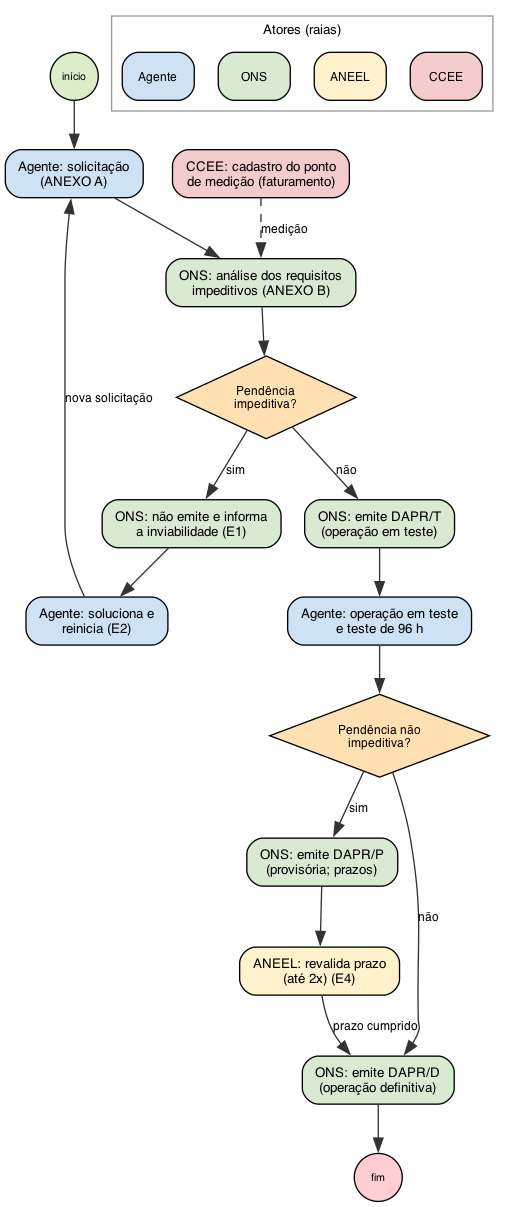

O fluxo principal acompanha a progressão das declarações ao longo do ciclo de integração. Parte da Declaração de Inexistência de Relacionamento Operacional (DIR), destinada às usinas sem impacto relevante no SIN, e avança para a Declaração de Atendimento aos Procedimentos de Rede em suas três modalidades sequenciais: a DAPR/T, para o início da operação em teste; a DAPR/P, para a operação provisória, que admite pendências não impeditivas com prazos acordados; e a DAPR/D, para a operação definitiva, condicionada à inexistência de pendências e à conclusão dos estudos pré-operacionais do Submódulo 7.4. Há, porém, um atalho. Quando o ONS verifica, já na análise inicial, que não há pendências para a operação integrada, o fluxo prevê a emissão direta da DAPR/D, sem passar pelas etapas intermediárias.

Dois gateways de decisão concentram a lógica de bifurcação do processo. Um deles distingue a existência ou não de pendência impeditiva. Havendo impedimento, o ONS suspende o processo, comunica a inviabilidade e o reinicia apenas após confirmação da solução e nova solicitação pelo sistema computacional. O outro gateway trata das pendências não impeditivas, que vinculam a operação a prazos e a eventuais restrições de escoamento sem bloqueá-la, conduzindo à emissão da DAPR/P. Os fluxos de exceção formalizam esses desvios. Complementam-nos a revalidação de prazo pela ANEEL, admitida até duas vezes mediante justificativa, e a comunicação ao órgão regulador.

A elicitação junto ao especialista acrescentou três requisitos que não emergem da leitura literal do Submódulo, mas que delimitam o comportamento real do processo. Um deles aponta a fase de teste como a etapa mais trabalhosa e geradora de pendências. Outro registra a persistência de pendências não impeditivas por anos, com o risco sistêmico associado ao apagão de agosto de 2023. O terceiro separa os requisitos objetivos, passíveis de automação, daqueles que dependem de avaliação de um especialista humano.

A Tabela 3 consolida os 36 elementos do modelo de referência, identificados pelos códigos utilizados na avaliação requisito a requisito.

**Tabela 3 – Elementos do modelo de referência do Submódulo 7.13**

| ID | Descrição | Categoria |
|----|-----------|-----------|
| A1 | Agente de Geração | Ator |
| A2 | ONS | Ator |
| A3 | ANEEL | Ator |
| A4 | CCEE | Ator |
| P1 | Solicitação de DIR pelo Agente de Geração | Atividade |
| P2 | Análise da solicitação de DIR pelo ONS | Atividade |
| P3 | Emissão da DIR | Atividade |
| P4 | Solicitação de DAPR/T pelo Agente de Geração | Atividade |
| P5 | Análise dos requisitos impeditivos para DAPR/T | Atividade |
| P6 | Emissão da DAPR/T | Atividade |
| P7 | Início da operação em teste | Atividade |
| P8 | Realização do teste de 96 horas | Atividade |
| P9 | Solicitação de DAPR/P pelo Agente de Geração | Atividade |
| P10 | Análise da DAPR/P com pendências não impeditivas e prazos | Atividade |
| P11 | Emissão da DAPR/P | Atividade |
| P12 | Emissão direta da DAPR/D (sem pendências) | Atividade |
| P13 | Solicitação e análise de DAPR/D | Atividade |
| P14 | Emissão da DAPR/D | Atividade |
| E1 | Pendência impeditiva conduz à não emissão da declaração | Fluxo de exceção |
| E2 | Suspensão do processo e reinício após confirmação da solução e nova solicitação | Fluxo de exceção |
| E3 | Pendência não impeditiva conduz à DAPR/P com prazo | Fluxo de exceção |
| E4 | Revalidação de prazo pela ANEEL, até duas vezes mediante justificativa | Fluxo de exceção |
| E5 | Comunicação à ANEEL | Fluxo de exceção |
| R1 | Conformidade com o Ato Autorizativo/outorga | Requisito documental/regulatório |
| R2 | Designação de interlocutores | Requisito documental/regulatório |
| R3 | Parecer de Acesso (Rede Básica, ICG ou DIT) e atendimento a ressalvas/pendências | Requisito documental/regulatório |
| R4 | Instrumento de garantia financeira e CUST com MUST vigente | Requisito documental/regulatório |
| R5 | Inexistência de inadimplência nos encargos de transmissão | Requisito documental/regulatório |
| R6 | CCT (Contrato de Conexão à Transmissão) | Requisito documental/regulatório |
| R7 | Diagrama unifilar (pré-operacional e operacional) | Requisito documental/regulatório |
| R8 | Medição para faturamento: aprovação do projeto e cadastro do ponto na CCEE | Requisito documental/regulatório |
| R9 | Telecomunicação, supervisão e controle (canais de dados e voz, base de dados, teste ponto a ponto, SOE) | Requisito documental/regulatório |
| R10 | Estudos pré-operacionais (Submódulo 7.4), comissionamento e validação de modelos | Requisito documental/regulatório |
| I1 | Fase de teste como etapa mais trabalhosa e geradora de pendências | Requisito implícito (entrevista) |
| I2 | Persistência de pendências por anos e risco sistêmico (apagão de agosto de 2023) | Requisito implícito (entrevista) |
| I3 | Distinção entre requisitos automatizáveis e os que demandam especialista humano | Requisito implícito (entrevista) |

### 5.2 Modelos gerados pelas LLMs

Antes de descrever o conteúdo de cada saída, registra-se o controle de completude adotado nesta rodada. A integridade de cada geração foi verificada pelo motivo de parada informado pela própria API, não por inspeção visual do texto. A saída do Sonnet 4.6 encerrou com `stop_reason=end_turn`, somando 33.824 caracteres sob um teto de 16.000 tokens. A do Haiku 4.5 também encerrou com `stop_reason=end_turn`, com 30.836 caracteres sob o mesmo teto de 16.000 tokens. A do Llama 3.3 70B encerrou com `finish_reason=stop`, com 2.631 caracteres sob um teto de 3.500 tokens. Nenhuma das três saídas foi interrompida por limite de geração. Os dois modelos da família Claude concluíram por conta própria bem antes do teto, e o Llama concluiu com folga substancial em relação ao seu. A diferença de extensão entre o Llama, com cerca de 2,6 mil caracteres, e os dois modelos Claude, com aproximadamente 31 mil e 34 mil caracteres, reflete comportamento do modelo. Não é artefato de truncamento de plataforma.

Cabe uma ressalva de não determinismo associada a essa verificação. Uma execução preliminar, conduzida com teto menor de 8.000 tokens (que de fato truncou as saídas dos dois Claude), produziu uma saída do Llama distinta e mais longa, com cerca de 4,4 mil caracteres, mesmo a temperatura zero. A variação entre execuções, mesmo com parâmetros nominalmente determinísticos, é evidência de não determinismo das plataformas e será tratada como limitação do estudo, dado que se trabalha com uma única geração por modelo.

#### 5.2.1 Sonnet 4.6

O Sonnet 4.6 produziu a saída mais completa entre os três. Capturou os quatro atores do modelo de referência (A1 Agente, A2 ONS, A3 ANEEL e A4 CCEE) e a totalidade das quatorze atividades P1 a P14. Recuperou também os cinco fluxos de exceção E1 a E5, sem omissões nessa dimensão. No conjunto de requisitos, contudo, identificou apenas R1, R3 e R10, deixando de fora R2, R4, R5, R6, R7, R8 e R9. Nenhum dos três conhecimentos implícitos da entrevista (I1, I2 e I3) foi recuperado, o que é coerente com o desenho do estudo, já que tais itens não constavam do documento fornecido.

A saída apresentou três elementos espúrios, todos plausíveis à primeira vista, mas sem respaldo no recorte documental utilizado. Um deles foi a inclusão de uma verificação prévia da classificação da usina por modalidade como subprocesso explícito. Outro foi o aguardo da conclusão de instalações vinculadas ao mesmo estudo pré-operacional, modelado como gateway ou fluxo de exceção. Havia ainda um tratamento especial para usinas do Tipo II-C com múltiplos circuitos, representado como atividade ou gateway paralelo. Os dois últimos correspondem a disposições presentes no texto fornecido (itens 3.2.6 e 3.3.3.2 do submódulo) que o modelo de referência, no seu nível de granularidade, não contempla como elementos distintos. São espúrios em relação ao gabarito e ilustram divergência de fronteira e de granularidade, mais do que invenção.

#### 5.2.2 Haiku 4.5

O Haiku 4.5 recuperou três dos quatro atores, omitindo A4 CCEE. Das quatorze atividades, capturou treze, deixando de fora P8, o teste de 96 horas. Recuperou integralmente os cinco fluxos de exceção E1 a E5. No conjunto de requisitos, identificou apenas R1 e R3, omitindo os outros oito. Como no caso anterior, não recuperou nenhum dos três conhecimentos implícitos.

Os três elementos espúrios do Haiku 4.5 também se concentram em estruturas inventadas a partir de inferência sobre o domínio. O modelo introduziu um Sistema Computacional do ONS (SGI) como ator com raia própria, embora o sistema não figure como participante do processo no material. Tratou reuniões operacionais entre agentes e ONS como fluxo de exceção formal, sem que tais reuniões integrem a sequência normativa. À semelhança do Sonnet, representou a situação de múltiplos circuitos para usinas do Tipo II-C, com DAPR/P concomitante, como fluxo de exceção explícito. A disposição consta do texto fornecido (item 3.2.6), mas o gabarito de 36 elementos não a contempla como elemento distinto, o que configura divergência de granularidade em relação à referência.

#### 5.2.3 Llama 3.3 70B

O Llama 3.3 70B gerou a saída mais curta e mais incompleta. Recuperou três atores, omitindo A4 CCEE. Das quatorze atividades, capturou nove (P1 a P6, P9, P13 e P14) e omitiu cinco: P7, o início da operação em teste; P8, o teste de 96 horas; P10 e P11, a análise e emissão da DAPR/P; e P12, a emissão direta da DAPR/D. Dos cinco fluxos de exceção, recuperou apenas E1 e E2, deixando de fora E3 (pendência não impeditiva levando à DAPR/P), E4 (revalidação pela ANEEL) e E5 (comunicação à ANEEL). Não recuperou nenhum dos dez requisitos, tampouco qualquer dos três implícitos.

A saída do Llama registra dois elementos espúrios. Um é um gateway de pendência impeditiva inventado para a DIR, sem respaldo no documento. O outro é o colapso da análise da DAPR/P em um fluxo genérico de pendências impeditivas, sem distinguir o ramo das pendências não impeditivas com prazo, que é justamente o que caracteriza a transição para a DAPR/P. O resultado é um modelo que captura apenas o esqueleto do fluxo principal e perde tanto a ramificação das exceções quanto a totalidade dos requisitos.

### 5.3 Resultados quantitativos

A hierarquia de desempenho é consistente em todas as métricas. Pelo F1, o Sonnet 4.6 lidera com 0,800, seguido pelo Haiku 4.5 com 0,742 e pelo Llama com 0,538. A taxa de cobertura de requisitos (TCR) ordena os modelos da mesma forma: 0,722 para o Sonnet, 0,639 para o Haiku e 0,389 para o Llama. A taxa de requisitos omitidos (TRO), complementar à cobertura, mostra o quadro inverso, com 0,278, 0,361 e 0,611, e o Llama deixando de fora a maior parte dos elementos do modelo de referência. Por construção, a revocação coincide com a TCR, pois ambas expressam a mesma fração de elementos do modelo de referência efetivamente recuperados. A identidade fica registrada para que a concordância entre as duas linhas da Tabela 4 não seja lida como confirmação independente entre métricas.

Um resultado desta rodada merece destaque por contrariar a leitura usual sobre o Llama. A taxa de elementos espúrios (TEE) é baixa para os três modelos (0,103 no Sonnet, 0,115 no Haiku e 0,125 no Llama), e a precisão também é alta e próxima nos três casos: 0,897, 0,885 e 0,875. O ponto relevante é que o Llama detém a menor precisão das três, não a maior. A narrativa de um modelo "conservador, porém preciso", que produziria menos elementos mas com maior acerto, não se sustenta nesta execução. O Llama produziu uma saída curta que captura apenas o esqueleto do fluxo principal e fica atrás nas três frentes simultaneamente, cobertura, precisão e F1. A brevidade não se converteu em parcimônia útil. Resultou em perda de cobertura sem ganho compensatório de precisão.

As omissões concentram-se de modo claro em duas categorias. A leitura por categoria (atores, atividades, exceções, requisitos e implícitos) mostra que o Sonnet omitiu 0, 0, 0, 7 e 3; o Haiku omitiu 1, 1, 0, 8 e 3; e o Llama omitiu 1, 5, 3, 10 e 3. Os requisitos e os implícitos respondem pela quase totalidade das omissões dos dois modelos Claude, que recuperaram bem atores, atividades e exceções e falharam sobretudo na extração dos requisitos do Tipo I. Os três implícitos foram omitidos por todos os modelos, o que era esperado. Por não constarem do documento fornecido, funcionam como controle de fronteira da extração documental e confirmam que nenhum dos modelos inventou conhecimento de entrevista. Como se verificou que todo o conteúdo de R1 a R10 estava presente no documento condensado, as omissões de requisitos não podem ser atribuídas ao recorte do material. São, efetivamente, falhas de extração dos modelos sobre um insumo que continha a informação.

**Tabela 4 – Resultados quantitativos do benchmark**

| Métrica | Sonnet 4.6 | Haiku 4.5 | Llama |
|---|---|---|---|
| Elementos identificados (n) | 26 | 23 | 14 |
| Elementos omitidos (n) | 10 | 13 | 22 |
| Elementos espúrios (n) | 3 | 3 | 2 |
| Taxa de Cobertura de Requisitos – TCR | 0,722 | 0,639 | 0,389 |
| Taxa de Requisitos Omitidos – TRO | 0,278 | 0,361 | 0,611 |
| Taxa de Elementos Espúrios – TEE | 0,103 | 0,115 | 0,125 |
| Precisão | 0,897 | 0,885 | 0,875 |
| Revocação (= TCR, por construção) | 0,722 | 0,639 | 0,389 |
| F1 | 0,800 | 0,742 | 0,538 |

**Tabela 5 – Omissões por categoria de elemento**

| Categoria (total de elementos) | Sonnet 4.6 | Haiku 4.5 | Llama |
|---|---|---|---|
| Atores (4) | 0 | 1 | 1 |
| Atividades (14) | 0 | 1 | 5 |
| Fluxos de exceção (5) | 0 | 0 | 3 |
| Requisitos documentais/regulatórios (10) | 7 | 8 | 10 |
| Requisitos implícitos (3) | 3 | 3 | 3 |

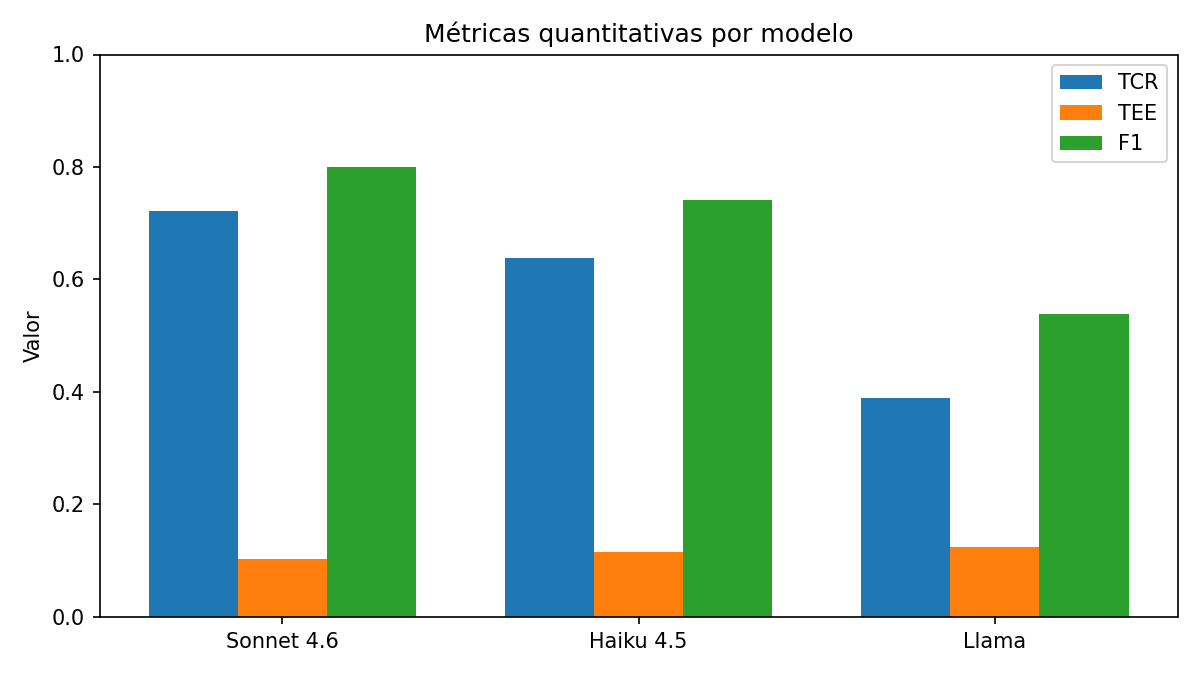

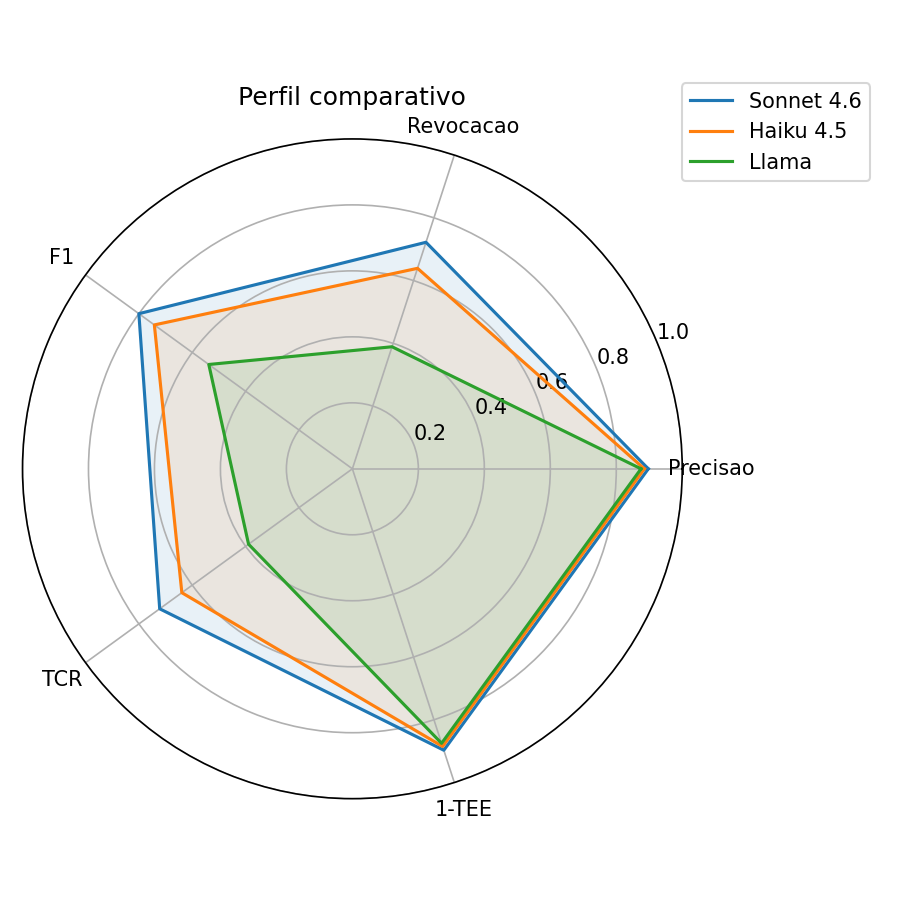

### 5.4 Leitura qualitativa das saídas

A apreciação qualitativa que se segue é uma leitura estruturada das saídas realizada pelos autores. Não houve atribuição de notas numéricas, escala Likert ou mais de um avaliador. Trata-se de rater único. A leitura foi conduzida após a análise quantitativa e tomando-a como referência, de modo que não é independente das métricas já apresentadas. O caráter dependente da leitura é declarado aqui e retomado entre as ameaças à validade, na seção 6.6. A organização segue as cinco dimensões do protocolo do Apêndice E.

Quanto à fidelidade semântica, o Sonnet 4.6 preserva o encadeamento normativo do processo de emissão das declarações de atendimento (DIR, DAPR/T, DAPR/P provisória e DAPR/D definitiva), incluindo as ramificações entre pendências impeditivas e não impeditivas. O Haiku 4.5 mantém o mesmo encadeamento principal, com uma lacuna pontual na fase de teste, ao não representar o teste de 96 horas. O Llama compromete a fidelidade num ponto sensível. Ao colapsar a análise da DAPR/P num fluxo genérico de pendências impeditivas, suprime a distinção que define a transição para o estágio provisório; e, ao omitir P10 a P12, deixa o desfecho do processo incompleto.

Na cobertura de atores, o Sonnet representa os quatro participantes, ao passo que Haiku e Llama omitem a CCEE, com efeito direto sobre as atividades que dependem desse ator, sobretudo as relativas a medição e adesão à câmara. A cobertura de fluxos de exceção separa os modelos de forma marcada. Sonnet e Haiku recuperam os cinco fluxos, enquanto o Llama recupera apenas dois e perde a revalidação pela ANEEL, a comunicação à agência e o ramo de pendência não impeditiva, exatamente os pontos que conferem ao modelo seu valor descritivo para situações fora do caminho principal.

Em estrutura e coerência, as três saídas são internamente consistentes naquilo que modelam, sem contradições de fluxo evidentes. A diferença está na presença de elementos espúrios. Sonnet e Haiku introduzem três cada um, em geral reconstruindo distinções de modalidade (o caso das usinas Tipo II-C com múltiplos circuitos aparece em ambos) ou elevando a participantes e exceções itens que não integram a sequência normativa, como o sistema SGI no Haiku. O Llama tem menos elementos espúrios em número absoluto (dois). Um deles, porém, afeta a coerência do desfecho, ao inventar um gateway de pendência impeditiva para a DIR.

Na utilidade prática, a leitura dos autores converge com a ordenação quantitativa. O modelo do Sonnet 4.6 é o mais próximo de um ponto de partida aproveitável para revisão por especialista, demandando sobretudo a inserção dos requisitos do Tipo I. O do Haiku 4.5 é aproveitável com ressalvas, exigindo reincorporar a CCEE e o teste de 96 horas, além dos requisitos. O do Llama exige mais. Por omitir a maior parte dos requisitos, parte das atividades terminais e a maioria das exceções, fornece pouco mais que um esboço do caminho feliz e exigiria reconstrução substancial antes de qualquer uso.

## 6 Discussão

### 6.1 Desempenho comparativo

A ordenação dos três modelos foi consistente nas métricas de cobertura e síntese. O Sonnet 4.6 identificou 26 dos 36 elementos do modelo de referência, com TCR de 0,722 e F1 de 0,800; o Haiku 4.5 ficou logo atrás, com 23 elementos, TCR de 0,639 e F1 de 0,742; o Llama 3.3 70B identificou apenas 14 elementos (TCR de 0,389, F1 de 0,538). A revocação coincide com o TCR por construção, pois ambos expressam a mesma fração de elementos do referencial efetivamente recuperados.

O dado que reorganiza a leitura em relação a expectativas correntes é a precisão. Nesta rodada o Llama não detém a maior precisão. Seus 0,875 são o menor valor das três saídas, abaixo dos 0,897 do Sonnet 4.6 e dos 0,885 do Haiku 4.5. A caracterização do modelo aberto como conservador, porém preciso, não se sustenta neste experimento. O Llama produziu uma saída curta (2.631 caracteres, contra 33.824 do Sonnet e 30.836 do Haiku) que captura apenas o esqueleto do fluxo principal e fica atrás dos demais nas três frentes ao mesmo tempo, isto é, em cobertura, em precisão e na capacidade de síntese medida pelo F1. A brevidade não decorre de limite de plataforma, já que o stop_reason confirmou conclusão por conta própria, com 2.631 caracteres contra um teto de 3.500 tokens. Decorre do comportamento do próprio modelo diante do mesmo insumo e do mesmo prompt.

O detalhamento por categoria torna o quadro mais legível. O Sonnet 4.6 recuperou os 4 atores, as 14 atividades e os 5 fluxos de exceção, concentrando suas 10 omissões em 7 requisitos e nos 3 implícitos da entrevista. O Haiku 4.5 omitiu um ator (A4 CCEE), uma atividade (P8, o teste de 96 horas), 8 requisitos e os 3 implícitos. O Llama omitiu um ator, 5 atividades, 3 dos 5 fluxos de exceção, a totalidade dos 10 requisitos e os 3 implícitos. A taxa de elementos espúrios manteve-se baixa e próxima entre os modelos (TEE de 0,103; 0,115; 0,125), o que indica que nenhum dos três alucinou estruturas em volume. O que separa os modelos é outra coisa. A diferença de desempenho está na quantidade de conteúdo legítimo que cada um deixou de recuperar.

### 6.2 Limitações no domínio do setor elétrico

A categoria de requisitos foi a que mais penalizou os três modelos. O Sonnet 4.6 recuperou apenas R1, R3 e R10; o Haiku 4.5, somente R1 e R3; e o Llama não recuperou nenhum dos dez. Convém afastar de imediato a hipótese de que essas omissões sejam artefato do recorte aplicado ao documento. Verificou-se empiricamente que todo o conteúdo de R1 a R10 estava presente no insumo condensado. A tabela de requisitos do Tipo I do Anexo B foi preservada de forma integral, incluindo ato autorizativo, interlocutores, parecer de acesso, garantia e contratos CUST/MUST, inadimplência, CCT, unifilar, medição e relação com a CCEE, telecomunicações e SOE, comissionamento e ensaios pré-operacionais, o teste de 96 horas e a ADS. O recorte removeu apenas a repetição das tabelas por modalidade (Tipos II-A, II-B, II-C e III), de modo que a única conclusão de fato limitada por ele é a relativa ao mapeamento entre requisito e modalidade. A omissão dos requisitos é, portanto, atribuível ao comportamento dos modelos, não à privação de informação.

O resultado dialoga com a literatura recente sobre o uso de modelos de linguagem na engenharia de requisitos. Ronanki (2024) observa que esses modelos tendem a recuperar com mais facilidade a estrutura de um processo do que as condições normativas que o regulam, e o presente experimento exibe exatamente esse padrão. Atores, atividades e gateways foram majoritariamente capturados, ao passo que os requisitos técnicos e regulatórios, que são o cerne do controle exercido pelo ONS sobre o acesso e a integração de instalações, escaparam de forma sistemática. Kuchenbuch, Lehnhoff e Sauer (2025), ao examinar a aplicação dessas ferramentas ao setor de energia, ressaltam que a densidade regulatória e a terminologia específica do domínio elevam a barreira de extração, sobretudo quando os requisitos aparecem em forma tabular e fortemente dependente de contexto. A perda quase completa dos requisitos pelo Llama e a perda majoritária pelos dois modelos da família Claude sugerem que a competência exibida na reconstrução do fluxo não se transfere automaticamente para o conteúdo normativo associado a esse fluxo.

### 6.3 O controle de fronteira do conhecimento tácito

Os três implícitos da entrevista (I1, a fase de teste como a mais trabalhosa; I2, as pendências que se arrastam por anos e o apagão de agosto de 2023; I3, a distinção entre o que é automatizável e o que exige especialista) foram omitidos pelos três modelos, em todos os casos (3/3/3). O resultado precisa ser interpretado com cuidado, porque não mede o que poderia parecer à primeira vista.

I1, I2 e I3, por definição, não estavam no insumo documental. São conhecimento elicitado em entrevista com o especialista e ausente do texto submetido aos modelos. Sua função no desenho experimental é a de controle de fronteira da extração documental: verificam se algum modelo inventaria informação de entrevista que não lhe foi fornecida. A omissão uniforme não atesta incapacidade de extrair conhecimento tácito, pois nenhum modelo teve a oportunidade de extraí-lo. O material de entrada não o continha. O que o resultado demonstra é que a extração a partir do documento não alcança aquilo que somente a elicitação humana traz, e esse é justamente o comportamento desejável. A ausência de I1-I3 nas três saídas é um sinal positivo de calibração, porque indica que os modelos se ativeram ao conteúdo fornecido e não fabricaram um saber experiencial que não tinham como conhecer. Tratar essa fronteira como medida de competência tácita seria confundir o que o controle foi projetado para detectar.

### 6.4 Papel da engenharia de prompts

A condição experimental adotada (zero-shot, temperatura zero, prompt textualmente idêntico para os três modelos) estabelece um piso de desempenho, não um teto. Ela mede o que cada modelo entrega sem exemplos, sem recuperação aumentada e sem instruções de domínio que o orientem na direção dos elementos esperados. Arvidsson e Axell (2023) mostram que a formulação do prompt e a oferta de exemplos deslocam de modo apreciável a qualidade da extração de requisitos, o que sugere margem de melhoria não explorada aqui por opção metodológica.

Há, contudo, um limite intrínseco a essa margem. Técnicas como few-shot e geração aumentada por recuperação poderiam plausivelmente recuperar parte dos requisitos omitidos, uma vez que o conteúdo de R1-R10 está disponível em fontes documentais e responde a melhor direcionamento ou a melhor acesso ao texto. Os implícitos I1-I3 permaneceriam fora do alcance dessas técnicas enquanto o conhecimento da entrevista não fosse incorporado à base consultada, porque nenhuma engenharia de prompt cria informação inexistente no material disponível ao modelo. A distinção é operacional. Aprimorar o prompt ataca a omissão de requisitos documentais, mas não substitui a elicitação humana que origina os implícitos.

### 6.5 Implicações para o ONS

O experimento sugere um uso delimitado e útil dessas ferramentas no contexto do ONS. Com o modelo mais capaz, a primeira camada estrutural do processo de emissão de declarações de atendimento, formada por atores, atividades e fluxos de exceção, foi reconstruída de forma confiável, pois o Sonnet 4.6 recuperou integralmente as três categorias. Essa camada é a que mais consome tempo manual na transcrição inicial de um processo normativo para notação BPMN, e sua automação parcial representa ganho concreto para a equipe de modelagem.

A camada de requisitos e de conhecimento operacional exige o especialista. A omissão de 7 a 10 requisitos por modelo e a ausência uniforme dos implícitos indicam que a validação técnica do que cada declaração (DIR, DAPR/T, DAPR/P provisória e DAPR/D definitiva) exige permanece tarefa humana. Um fluxo de trabalho plausível para a Superintendência de Integração seria empregar o modelo de linguagem para gerar o rascunho estrutural e reservar a revisão do especialista para a inserção dos requisitos e do conhecimento experiencial, em vez de delegar à ferramenta a extração completa do processo.

### 6.6 Ameaças à validade

A ameaça mais séria deste estudo é a escolha do juiz. O pareamento e a contagem de elementos foram realizados por um modelo de linguagem (Claude Sonnet 4.6) que pertence à mesma família de dois dos três avaliados e que é, ele próprio, o modelo mais bem avaliado da rodada. Não se aplicou mitigação a essa circunstância. Não houve juiz humano independente, nem juiz de família distinta, nem cegamento da origem das saídas, de modo que não se pode descartar viés favorável às respostas estilística ou estruturalmente próximas às do avaliador. Registra-se essa limitação sem atenuá-la.

A apreciação qualitativa das saídas foi conduzida segundo as dimensões do Apêndice E (fidelidade semântica, cobertura de atores, cobertura de fluxos de exceção, estrutura e coerência, utilidade prática), pelos próprios autores, em rater único, após a análise quantitativa e à luz dela. Não constitui, portanto, avaliação independente das métricas. A leitura foi informada pelos números já calculados e pode ter sido por eles ancorada. Não há escala Likert nem notas atribuídas. O que se apresenta é uma leitura estruturada em prosa, e seu caráter não independente é aqui declarado de forma explícita.

O tamanho amostral é n=1 por modelo, e o não-determinismo entre execuções foi observado, não apenas conjeturado. Uma execução preliminar, com teto de geração menor (8.000 tokens, que truncou as saídas dos dois modelos Claude), produziu uma resposta do Llama distinta e mais longa (4.400 caracteres) mesmo à temperatura zero. A variação de uma mesma configuração entre rodadas demonstra que uma única amostra por modelo não captura a dispersão do comportamento e que as métricas reportadas devem ser lidas como uma realização, não como média estável.

A completude das três saídas da rodada definitiva foi verificada pelo stop_reason retornado pela API: end_turn para Sonnet 4.6 (33.824 caracteres) e Haiku 4.5 (30.836 caracteres), ambos com teto de 16.000 tokens, e finish_reason=stop para o Llama (2.631 caracteres, teto de 3.500 tokens), este concluindo muito abaixo do limite. Nenhuma saída foi truncada, e a diferença de extensão é comportamento dos modelos. Permanece, ainda assim, uma diferença de condição entre plataformas, pois os tetos de geração não foram idênticos (16.000 tokens no Bedrock, 3.500 no Groq). Embora a verificação por stop_reason afaste o truncamento como explicação, a assimetria de teto é uma diferença experimental que se reconhece.

O insumo condensado preserva integralmente o conteúdo dos requisitos avaliados, como verificado na seção 6.2, mas remove a repetição das tabelas por modalidade. Disso decorre uma limitação circunscrita. As conclusões sobre o mapeamento entre requisito e modalidade ficam comprometidas, ainda que as conclusões sobre a recuperação dos requisitos em si não fiquem. Restam, ainda, os limites de escopo. O modelo de referência tem fonte única, um especialista, e o estudo cobre um único submódulo. A generalização para outros processos do ONS, para outros especialistas e para outras configurações de geração exige replicação que este desenho não oferece.

## 7 Conclusão

Este artigo investigou em que medida modelos de linguagem de grande porte conseguem extrair, de um documento normativo do setor elétrico brasileiro, os elementos necessários à modelagem do processo de emissão de declarações de atendimento (DIR, DAPR/T, DAPR/P provisória e DAPR/D definitiva), previsto no Submódulo 7.13 dos Procedimentos de Rede do ONS. A apuração se deu sobre um gabarito de 36 elementos e três saídas geradas em condições idênticas. Os resultados confirmam que o desempenho é governado pela capacidade do modelo, não pela categoria do elemento isoladamente.

O modelo de referência foi construído conforme o objetivo (a). A partir do documento normativo e da entrevista com o especialista, consolidou-se um gabarito em BPMN com 36 elementos, distribuídos em 4 atores (Agente, ONS, ANEEL e CCEE), 14 atividades, 5 fluxos de exceção, 10 requisitos documentais e 3 requisitos implícitos oriundos exclusivamente da entrevista. Os três implícitos (a fase de teste como etapa mais trabalhosa, as pendências arrastadas por anos e associadas ao apagão de agosto de 2023, e a distinção entre o que é automatizável e o que exige o especialista) não figuram no documento. Funcionaram como controle de fronteira da extração documental, não como medida de captura de conhecimento tácito.

A submissão seguiu o objetivo (b). Os três modelos receberam um prompt textualmente idêntico, em regime zero-shot e temperatura zero, sobre o mesmo insumo condensado. A completude das saídas foi verificada pelo stop_reason retornado pela API. Sonnet 4.6 (33.824 caracteres) e Haiku 4.5 (30.836 caracteres) encerraram por conta própria sob teto de 16.000 tokens, e o Llama 3.3 70B (2.631 caracteres) também concluiu espontaneamente, bem abaixo do teto de 3.500 tokens. Nada foi truncado. A diferença de extensão entre o Llama e os dois modelos da família Claude é comportamento de geração, não limite de plataforma.

O pareamento requisito a requisito e o cálculo das métricas atenderam ao objetivo (c). Sonnet 4.6 alcançou TCR de 0,722, TRO de 0,278, TEE de 0,103, precisão de 0,897, revocação de 0,722 e F1 de 0,800. Haiku 4.5 registrou TCR de 0,639, TRO de 0,361, TEE de 0,115, precisão de 0,885, revocação de 0,639 e F1 de 0,742. O Llama obteve TCR de 0,389, TRO de 0,611, TEE de 0,125, precisão de 0,875, revocação de 0,389 e F1 de 0,538. Por construção, a revocação coincide com a TCR em cada modelo, pois exprimem a mesma fração de elementos do gabarito recuperados.

A análise comparativa, prevista no objetivo (d), mostra um ordenamento consistente nas três frentes de cobertura, precisão e F1. Sonnet 4.6 reproduziu integralmente a estrutura de controle do processo. Capturou os 4 atores, as 14 atividades e os 5 fluxos de exceção, falhando apenas em 7 dos 10 requisitos documentais (recuperou R1, R3 e R10) e em todos os implícitos. Haiku 4.5 perdeu um ator (CCEE), uma atividade (o teste de 96 horas) e 8 requisitos, mas preservou os cinco fluxos de exceção. O Llama capturou só o esqueleto do fluxo principal, com 3 atores, 9 atividades, 2 fluxos de exceção e nenhum dos 10 requisitos documentais, situando-se atrás dos demais inclusive em precisão, a menor das três (0,875). A narrativa de um modelo conservador, porém preciso, não se sustenta nesta rodada. As omissões concentraram-se nos requisitos documentais, ainda que todo o conteúdo de R1 a R10 estivesse presente no insumo condensado, o que afasta a hipótese de que a omissão seja artefato do recorte. Os três modelos não reproduziram nenhum dos três requisitos implícitos, comportamento esperado para a fronteira da extração documental e que sugere ausência de invenção de conhecimento ausente do texto. A apreciação qualitativa foi conduzida pelos autores como leitura estruturada das saídas, com rater único, posterior à análise quantitativa e a ela não independente, segundo as dimensões do Apêndice E. Tal leitura reforça o mesmo ordenamento.

A contribuição central é metodológica e empírica. Trata-se da primeira avaliação empírica do uso de modelos de linguagem para extração de conhecimento de processo a partir de um documento normativo do setor elétrico brasileiro, com gabarito explícito, pareamento elemento a elemento e métricas reproduzíveis. Permanece como limitação relevante o desenho de execução única por modelo (n=1), agravado pela evidência de não determinismo já observada em uma execução preliminar. Pesa também o uso de um juiz LLM (Claude Sonnet 4.6) que pertence à mesma família de dois dos avaliados e foi ele próprio o de melhor desempenho, ameaça à validade que se registra sem mitigação no desenho atual.

### 7.1 Trabalhos futuros

A dependência de um único juiz da mesma família dos avaliados pede substituição por juízes independentes e por pareamento humano, de modo a desacoplar a avaliação do espaço de modelos sob teste. O caráter de execução única (n=1) deve ceder lugar a k repetições por modelo, com reporte de variância e de intervalos, condição necessária diante do não determinismo observado mesmo a temperatura zero. Cabe ainda contrastar o regime zero-shot aqui empregado com estratégias de few-shot e de geração aumentada por recuperação (RAG), que podem reduzir as omissões concentradas nos requisitos documentais. O uso do documento normativo integral, em lugar do insumo condensado, permitiria avaliar o mapeamento entre requisito e modalidade, que o recorte das tabelas repetidas por tipo deixou fora do alcance das conclusões. A extensão a outros submódulos dos Procedimentos de Rede ampliaria a validade externa dos achados. Recomenda-se, por último, uma avaliação qualitativa independente, com múltiplos avaliadores e medida de concordância, separando a leitura interpretativa das métricas quantitativas.

## Referências

ARVIDSSON, Simon; AXELL, Johan. Prompt engineering guidelines for LLMs in Requirements Engineering. 2023. Bachelor of Science Thesis (Software Engineering and Management) – University of Gothenburg; Chalmers University of Technology, Gothenburg, 2023.

KHAN, Javed Ali; QAYYUM, Shamaila; DAR, Hafsa Shareef. Large Language Model for Requirements Engineering: A Systematic Literature Review. Research Square, 2024. Preprint. DOI: 10.21203/rs.3.rs-5589929/v1.

KUCHENBUCH, René; LEHNHOFF, Sebastian; SAUER, Jürgen. Smart Grid Assistive AI in Requirement Engineering: Improving the Modeling of Use Cases and Architecture Models with LLMs. In: PROCEEDINGS OF THE 16TH ACM INTERNATIONAL CONFERENCE ON FUTURE AND SUSTAINABLE ENERGY SYSTEMS (e-Energy '25). Rotterdam: ACM, 2025. p. 495-504. DOI: 10.1145/3679240.3734601.

NUSEIBEH, Bashar; EASTERBROOK, Steve. Requirements Engineering: A Roadmap. In: PROCEEDINGS OF THE CONFERENCE ON THE FUTURE OF SOFTWARE ENGINEERING (ICSE '00). Limerick, Irlanda: ACM, 2000. p. 35-46. DOI: 10.1145/336512.336523.

OLIVEIRA, Giusepe Tessari Lopes de. Aplicação de LLMs na modelagem de requisitos: melhorando a criação de diagramas UML e estimulando a criatividade em novos casos de uso. 2024. Trabalho de Conclusão de Curso (Bacharelado em Ciência da Computação) – Instituto de Informática, Universidade Federal do Rio Grande do Sul, Porto Alegre, 2024.

RONANKI, Krishna. Enhancing Requirements Engineering Practices Using Large Language Models. 2024. Licentiate Thesis (Licentiate of Engineering) – Chalmers University of Technology, Gothenburg, 2024.

RONANKI, Krishna; BERGER, Christian; HORKOFF, Jennifer. Investigating ChatGPT's Potential to Assist in Requirements Elicitation Processes. In: 49TH EUROMICRO CONFERENCE ON SOFTWARE ENGINEERING AND ADVANCED APPLICATIONS (SEAA), 2023, Durrës, Albânia. Anais [...]. IEEE, 2023. DOI: 10.1109/SEAA60479.2023.00061.

SANTOS, Reine et al. User Stories: Does ChatGPT Do It Better? In: INTERNATIONAL CONFERENCE ON ENTERPRISE INFORMATION SYSTEMS (ICEIS), 27., 2025, Porto. Anais [...]. SciTePress, 2025. v. 2, p. 47-58.

SILVA, Equiton Gomes da. Uso de LLMs em atividades de Engenharia de Requisitos: um estudo empírico. 2025. Trabalho de Conclusão de Curso (Graduação em Sistemas de Informação) – Universidade Federal Rural do Semi-Árido, Angicos, 2025.

ZADENOORI, Mohammad Amin et al. Large Language Models (LLMs) for Requirements Engineering (RE): A Systematic Literature Review. arXiv, 2025. arXiv:2509.11446.

## Apêndices

### Apêndice A – Roteiro de Entrevista Semiestruturada

A entrevista foi conduzida sob formato semiestruturado, em que as perguntas norteadoras serviram de ancoragem temática sem cercear a fala do entrevistado. O roteiro abaixo reproduz a estrutura aplicada na conversa com o especialista de integração da área de geração do ONS, organizada em sete blocos. As perguntas funcionaram como gatilhos; a ordem efetiva variou conforme o curso natural do diálogo, e desdobramentos espontâneos foram acompanhados quando agregavam à compreensão do processo do Submódulo 7.13.

**Bloco 1 – Caracterização do entrevistado e da área**

- Qual é a sua função na área de integração e há quanto tempo atua com a integração de instalações de geração ao SIN?
- Como a equipe está organizada e quais tipos de agente ela atende além da geração?
- Qual é o volume aproximado de solicitações que a área recebe e como esse volume se distribui entre os tipos de declaração?

**Bloco 2 – Visão geral do processo de integração**

- Em linhas gerais, por onde começa o processo de integração de uma nova instalação de geração e quais são as etapas até a entrada em operação?
- Como o parecer de acesso, o contrato, a autorização da ANEEL e a fase de construção se encadeiam até a avaliação dos requisitos pelo ONS?
- Quais documentos e informações o agente de geração encaminha ao ONS para dar início à solicitação?

**Bloco 3 – Tipos de declaração e modalidades de operação**

- Quais são as declarações emitidas pelo ONS no escopo do Submódulo 7.13 e o que distingue cada uma delas?
- Em que situações se aplica a Declaração de Inexistência de Relacionamento Operacional (DIR) e que tipo de usina ela costuma atender?
- Como as modalidades de operação (Tipo I, II-A, II-B, II-C e Tipo III) influenciam o conjunto de requisitos exigidos?
- Existe a possibilidade de emissão direta da declaração de operação definitiva sem passar pelas etapas intermediárias? Em que condições?

**Bloco 4 – Avaliação de requisitos e pendências**

- Quais etapas concentram maior esforço de análise e por quê?
- Como o ONS trata um requisito impeditivo identificado durante a avaliação? O que ocorre com o processo nesse caso?
- Qual é a diferença prática entre uma pendência impeditiva e uma pendência não impeditiva do ponto de vista do andamento do processo?
- Após a identificação de uma pendência impeditiva, como se dá a suspensão e a posterior retomada da solicitação?

**Bloco 5 – Operação provisória, prazos e risco sistêmico**

- A operação provisória admite pendências não impeditivas com prazos acordados. Como esses prazos são definidos e revalidados?
- As pendências não impeditivas tendem a ser resolvidas com rapidez ou podem perdurar? O que motiva eventuais atrasos?
- Há algum episódio em que pendências não resolvidas tenham contribuído para problemas operativos no sistema?
- Que mudanças de processo foram introduzidas para incentivar a resolução dessas pendências?

**Bloco 6 – Sistemas de apoio e automação**

- Quais ferramentas computacionais apoiam hoje a condução das solicitações e quais são suas limitações?
- Há iniciativas em desenvolvimento para integrar bases de dados externas (ANEEL, contratos, pareceres) e automatizar a criação de processos?
- Existe algum uso já consolidado de inteligência artificial em atividades correlatas dentro do ONS?
- Quais requisitos do Anexo B você considera passíveis de automação e quais permaneceriam dependentes de avaliação de especialista? Como traçar essa fronteira?

**Bloco 7 – Conformidade e exceções**

- O ONS adota desvios em relação ao procedimento estabelecido no Submódulo 7.13?
- Em que circunstâncias exceções pontuais podem ser concedidas e por qual instância?
- Há algum aspecto do processo que você considere relevante e que não tenha sido abordado nas perguntas anteriores?

###

### Apêndice B – Prompts utilizados no benchmark

Prompt único e idêntico para os três modelos (temperatura 0; zero-shot; primeira resposta). O insumo foi a versão condensada do Submódulo 7.13 (sem as tabelas repetidas do ANEXO B para as modalidades Tipo II-A, II-B, II-C e III).

**Prompt de papel (system):**

> Você é um analista especialista em Modelagem de Processos de Negócio (BPMN) atuando no setor elétrico brasileiro. Você conhece os Procedimentos de Rede do ONS e modela processos normativos com rigor, identificando atores (raias), atividades, eventos, gateways de decisão e fluxos de exceção.

**Prompt de tarefa (usuário):**

> Tarefa: a partir do documento normativo abaixo (Submódulo 7.13 dos Procedimentos de Rede do ONS), produza um MODELO DE PROCESSO DE NEGÓCIO em notação BPMN do processo de emissão das declarações de atendimento (DIR, DAPR/T, DAPR/P e DAPR/D) para integração de instalações de geração ao SIN.
>
> Entregue, em texto estruturado: (1) RAIAS (pools/lanes): liste todos os atores envolvidos; (2) ATIVIDADES: liste as atividades/tarefas do processo, na ordem, indicando o ator responsável; (3) GATEWAYS / DECISÕES: pontos de decisão (ex.: existência de pendências impeditivas); (4) EVENTOS: início, fim e eventos intermediários relevantes; (5) FLUXOS DE EXCEÇÃO: caminhos alternativos (ex.: não emissão, suspensão e reinício, prazos); (6) FLUXO DE SEQUÊNCIA: descreva a ordem das atividades e desvios. Seja completo e fiel ao documento. Não invente etapas que não constem do normativo.
>
> ===== DOCUMENTO (Submódulo 7.13) ===== [texto integral do submódulo]

### Apêndice C – Modelo de Referência Completo (*ground truth*)

O modelo de referência reúne os 36 elementos avaliados no pareamento requisito a requisito, com os mesmos
códigos e descrições da Tabela 3 – a codificação usada pelo avaliador automatizado e citada nas Seções 5 e 6.
Em BPMN, o processo se organiza em quatro raias (A1 a A4); o fluxo é estruturado por dois gateways de decisão
(existência de pendência impeditiva; existência de pendência não impeditiva) e por eventos de início e fim,
que articulam os elementos abaixo mas não integram a contagem dos 36.

**Atores (raias)**

- A1 – Agente de Geração
- A2 – ONS
- A3 – ANEEL
- A4 – CCEE

**Atividades**

- P1 – Solicitação de DIR pelo Agente de Geração
- P2 – Análise da solicitação de DIR pelo ONS
- P3 – Emissão da DIR
- P4 – Solicitação de DAPR/T pelo Agente de Geração
- P5 – Análise dos requisitos impeditivos para DAPR/T
- P6 – Emissão da DAPR/T
- P7 – Início da operação em teste
- P8 – Realização do teste de 96 horas
- P9 – Solicitação de DAPR/P pelo Agente de Geração
- P10 – Análise da DAPR/P com pendências não impeditivas e prazos
- P11 – Emissão da DAPR/P
- P12 – Emissão direta da DAPR/D (sem pendências)
- P13 – Solicitação e análise de DAPR/D
- P14 – Emissão da DAPR/D

**Fluxos de exceção**

- E1 – Pendência impeditiva conduz à não emissão da declaração
- E2 – Suspensão do processo e reinício após confirmação da solução e nova solicitação
- E3 – Pendência não impeditiva conduz à DAPR/P com prazo
- E4 – Revalidação de prazo pela ANEEL, até duas vezes mediante justificativa
- E5 – Comunicação à ANEEL

**Requisitos documentais e regulatórios**

- R1 – Conformidade com o Ato Autorizativo/outorga
- R2 – Designação de interlocutores
- R3 – Parecer de Acesso (Rede Básica, ICG ou DIT) e atendimento a ressalvas/pendências
- R4 – Instrumento de garantia financeira e CUST com MUST vigente
- R5 – Inexistência de inadimplência nos encargos de transmissão
- R6 – CCT (Contrato de Conexão à Transmissão)
- R7 – Diagrama unifilar (pré-operacional e operacional)
- R8 – Medição para faturamento: aprovação do projeto e cadastro do ponto na CCEE
- R9 – Telecomunicação, supervisão e controle (canais de dados e voz, base de dados, teste ponto a ponto, SOE)
- R10 – Estudos pré-operacionais (Submódulo 7.4), comissionamento e validação de modelos

**Requisitos implícitos (entrevista)**

- I1 – Fase de teste como etapa mais trabalhosa e geradora de pendências
- I2 – Persistência de pendências por anos e risco sistêmico (apagão de agosto de 2023)
- I3 – Distinção entre requisitos automatizáveis e os que demandam especialista humano

### Apêndice D – Modelos gerados pelas LLMs (saídas integrais)

As saídas brutas das três LLMs, preservadas sem edição para fins de reprodutibilidade, foram geradas pelo notebook `FPNSi_PPGI_Experimento.ipynb` e estão arquivadas em `dados/saidas/` (`Sonnet_4.6.md`, `Haiku_4.5.md` e `Llama.md`). As avaliações do pareamento requisito a requisito, produzidas pelo avaliador automatizado, estão em `dados/saidas/aval_*.json`.

### Apêndice E – Protocolo de Avaliação Qualitativa

A avaliação qualitativa complementa as métricas quantitativas de matching (TCR, TRO, TEE, Precisão, Revocação e F1), capturando atributos do modelo que a contagem requisito a requisito não alcança. Cada saída de LLM é pontuada em cinco dimensões, numa escala de 1 a 5, segundo as âncoras descritas a seguir. A pontuação é atribuída por análise do modelo gerado frente ao modelo de referência (Apêndice C) e ao texto do Submódulo 7.13. Cabe registrar que o uso de um avaliador automatizado, quando aplicável, configura ameaça à validade discutida no corpo do artigo.

Neste estudo, as cinco dimensões abaixo serviram de roteiro para a leitura estruturada das saídas relatada na Seção 5.4, conduzida por avaliador único. As âncoras numéricas de 1 a 5 não foram aplicadas; ficam registradas como instrumento para uma avaliação independente futura, com múltiplos avaliadores e medida de concordância.

**Dimensão 1 – Fidelidade Semântica**

Mede em que grau os elementos modelados correspondem fielmente ao significado do processo descrito no Submódulo 7.13, sem distorção de regras ou inversão de etapas.

- 1 – O modelo deturpa o processo: confunde declarações, inverte a ordem das etapas ou contradiz regras do submódulo.
- 2 – Captura a ideia geral, mas com erros semânticos relevantes que comprometeriam a execução real do processo.
- 3 – Representa corretamente o núcleo do processo, com imprecisões pontuais em condições ou nomenclatura.
- 4 – Fiel ao submódulo, com no máximo desvios menores sem impacto na lógica do processo.
- 5 – Correspondência semântica integral; declarações, condições e encadeamentos refletem com exatidão o texto normativo.

**Dimensão 2 – Cobertura de Atores**

Avalia a presença e a correta atribuição de responsabilidades às raias Agente de Geração, ONS, ANEEL e CCEE.

- 1 – Apenas um ator representado ou raias sem correspondência com o processo.
- 2 – Dois atores presentes; atribuições de responsabilidade majoritariamente equivocadas.
- 3 – Três atores presentes, ou os quatro presentes com atribuições parcialmente trocadas.
- 4 – Os quatro atores presentes, com poucas atividades alocadas à raia incorreta.
- 5 – Os quatro atores presentes e cada atividade corretamente atribuída à sua raia.

**Dimensão 3 – Cobertura de Fluxos de Exceção**

Verifica a representação dos cinco fluxos de exceção (E1 a E5): não emissão por pendência impeditiva, suspensão e reinício, encaminhamento à operação provisória, revalidação de prazo pela ANEEL e comunicação à ANEEL.

- 1 – Nenhum fluxo de exceção modelado; somente o caminho principal.
- 2 – Um fluxo de exceção representado.
- 3 – Dois a três fluxos de exceção representados, ainda que de forma simplificada.
- 4 – Quatro fluxos de exceção representados com lógica de desvio adequada.
- 5 – Os cinco fluxos de exceção representados, com gateways e retornos coerentes com o processo.

**Dimensão 4 – Estrutura e Coerência**

Examina o emprego correto dos construtos BPMN – eventos de início e fim, gateways, sequência de fluxos – e a ausência de inconsistências estruturais como caminhos sem saída ou desvios mal formados.

- 1 – Estrutura desorganizada; construtos BPMN ausentes ou mal empregados, com fluxos incoerentes.
- 2 – Construtos básicos presentes, porém com inconsistências estruturais frequentes.
- 3 – Estrutura compreensível, com uso parcial de gateways e eventos e algumas inconsistências.
- 4 – Estrutura coerente e bem formada, com lapsos estruturais isolados.
- 5 – Modelo estruturalmente íntegro: eventos, gateways e fluxos bem definidos, sem caminhos órfãos ou ambiguidade.

**Dimensão 5 – Utilidade Prática**

Estima o quanto o modelo serviria, na forma gerada, como insumo de trabalho para um especialista de integração, considerando o esforço de revisão necessário antes do uso.

- 1 – Inaproveitável; exigiria refazer o modelo do zero.
- 2 – Aproveitável apenas como esboço inicial, com retrabalho extenso.
- 3 – Útil como ponto de partida, demandando revisão substancial.
- 4 – Diretamente útil, requerendo apenas ajustes pontuais.
- 5 – Pronto para uso com revisão mínima; agrega valor imediato ao trabalho do especialista.
